# IFESS 2026 Hands-on — Neuro-musculoskeletal modeling for epidural spinal cord stimulation (eSCS)

### From spinal stimulation to movement: exploring how epidural stimulation generates muscle activation and joint motion

In this hands-on session, we build a computational pipeline that transforms **epidural spinal cord stimulation parameters** into **predicted lower-limb movement**.

In clinical practice, we observe the movement produced by a stimulation protocol, but we cannot directly observe the physiological mechanisms that generate it. Computational models bridge this gap by estimating each stage from electrical stimulation to muscle activation and, ultimately, movement:

<center>
<b>stimulation protocol → sensory-fiber extracellular potentials → sensory-fiber activation → muscle activation → joint dynamics </b>
</center>

By the end of this tutorial, you will be able to:

- understand how sensory-fiber recruitment can be predicted from a stimulation protocol;
- estimate the resulting muscle recruitment;
- simulate how evoked muscle activations generate movement;
- compare sensory-fiber recruitment, muscle recruitment, and the resulting joint kinematics across different stimulation protocols.

> **To keep the workflow easy to follow and computationally efficient, the notebook adopts a simplified neuromusculoskeletal modeling framework while preserving the key physiological mechanisms underlying epidural spinal cord stimulation.**

## 0. Setup

Run this section once at the beginning of the notebook. The required Python packages are installed from the provided `requirements.txt` file.


In [1]:
# %pip install -q -r requirements.txt

In [2]:
import ifes_utils
import ifes_visualization
import importlib

importlib.reload(ifes_utils)
importlib.reload(ifes_visualization)

<module 'ifes_visualization' from '/Users/nicolegiannotto/Desktop/PhD/Conferenze/IFES26/code/ifes_visualization.py'>

In [3]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import mujoco
import importlib
from ifes_utils import (
    FEM_REFERENCE_CURRENT_MA,
    plot_electrical_model,
    build_lfm,
    load_mujoco_model,
    get_actuator_names,
    create_actuator_mapping_table,
    map_muscle_recruitment_to_actuators,
    forward_dynamics,
)
from ifes_visualization import (plot_pattern_summary, plot_rootlet_extracellular_potentials)

print("✓ Dependencies and utilities imported")

# Project paths
CWD = Path.cwd()

if (CWD / "lfm").exists() and (CWD / "data").exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / "lfm").exists() and (CWD.parent / "data").exists():
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = CWD

RAW_LFM_FOLDER = PROJECT_ROOT / "lfm"
MODEL_XML = PROJECT_ROOT / "data" / "myo_sim" / "leg" / "myolegs_suspended.xml"
OUTPUT_FOLDER = PROJECT_ROOT / "results"

OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("LFM folder   :", RAW_LFM_FOLDER)
print("Model        :", MODEL_XML)
print("Results      :", OUTPUT_FOLDER)

✓ Dependencies and utilities imported
Project root : /Users/nicolegiannotto/Desktop/PhD/Conferenze/IFES26/code
LFM folder   : /Users/nicolegiannotto/Desktop/PhD/Conferenze/IFES26/code/lfm
Model        : /Users/nicolegiannotto/Desktop/PhD/Conferenze/IFES26/code/data/myo_sim/leg/myolegs_suspended.xml
Results      : /Users/nicolegiannotto/Desktop/PhD/Conferenze/IFES26/code/results


# 1. From epidural stimulation to sensory-fiber recruitment

> **Scientific question:** Given an electrode and a stimulation current, which sensory afferent fibers are recruited?

This first section connects the stimulation delivered through the epidural paddle to the sensory fibers located in the dorsal rootlets.

### Roadmap

<center>
<b>paddle array and anatomical data → eSCS volume-conductor model → FEM extracellular potentials → lead field matrix → sensory-fiber recruitment</b>
</center>

The volume-conduction and FEM simulations were performed **offline in COMSOL Multiphysics**. In the notebook, we build the LFM and use it to rapidly evaluate new stimulation patterns.


## 1.1 Simplified spinal-cord volume-conductor model

> **Question:** How does current injected in the epidural space spread toward the dorsal roots?

The lumbosacral spinal cord and surrounding tissues are represented using a simplified **concentric cylindrical volume-conductor model**, extending approximately from L1 to S2.

Six conductive compartments are included:

<div align="center">

<table style="font-size:85%; width:40%;">
<tr>
<th>Tissue</th>
<th>Conductivity</th>
</tr>
<tr><td>Grey matter</td><td>0.23 S/m</td></tr>
<tr><td>White matter</td><td>0.60 S/m longitudinal, 0.083 S/m transverse</td></tr>
<tr><td>Cerebrospinal fluid</td><td>1.70 S/m</td></tr>
<tr><td>Epidural fat</td><td>0.04 S/m</td></tr>
<tr><td>Vertebral bone</td><td>0.02 S/m</td></tr>
<tr><td>Other surrounding tissues</td><td>2.00 S/m</td></tr>
</table>

</div>

The conductivity values are based on **Capogrosso et al. (2013)** [1]. Most compartments are modeled as isotropic, whereas white matter is anisotropic to account for its higher conductivity along the rostro-caudal direction.

This geometry is intentionally simplified: the goal of the hands-on is to understand the complete stimulation-to-movement pipeline rather than reproduce every anatomical detail of the spinal cord.


## 1.2 Epidural paddle array

> **Question:** How is stimulation delivered to the model?

Stimulation is modeled using the **Boston Scientific CoverEdge X 32** paddle lead used in our clinical setup. The paddle contains **32 active sites arranged in four columns of eight electrodes**. In the simplified electrical model, each electrode is represented as a **point current source** positioned at the center of the corresponding physical contact.

The paddle is placed in the epidural space, close to the dorsal surface of the spinal cord. Its geometry therefore determines where injected current enters the volume conductor and strongly influences which dorsal rootlets are preferentially recruited.

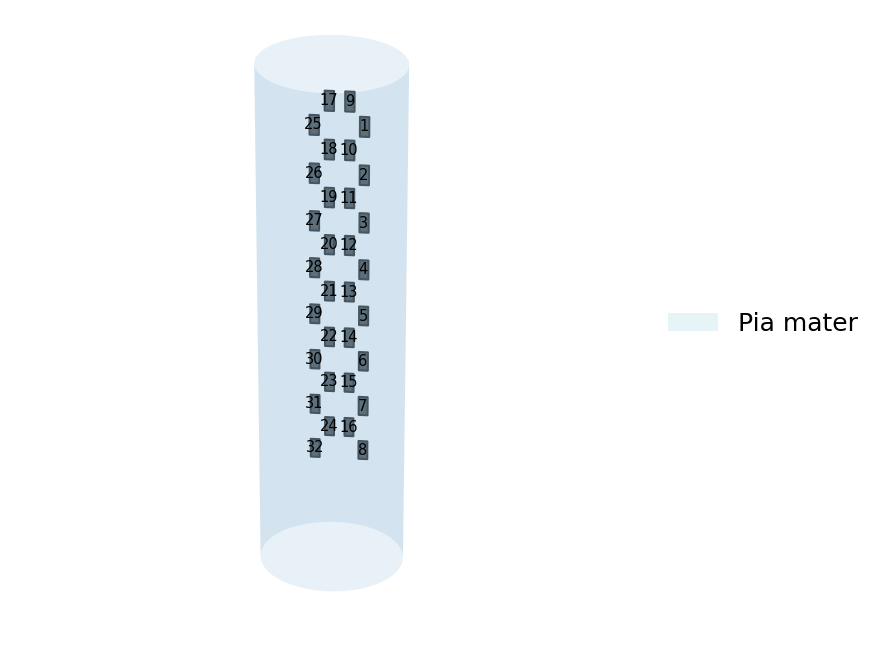

In [4]:
plot_electrical_model(rootlets=False, labels=True)

## 1.3 Representative sensory fibers

> **Question:** Where do we evaluate the extracellular potential?

We do not explicitly model every sensory axon in a dorsal root. Instead, each dorsal rootlet is represented by a set of **representative sensory-fiber locations**. For every lumbosacral segment from **L1 to S2**, dorsal rootlets are positioned along the rostro-caudal axis. Representative fiber locations are distributed within each rootlet, so every modeled fiber is associated with a position

$$
(x_f,\;y_f,\;z_f).
$$

At this stage, these locations only describe **where the sensory fibers are**.


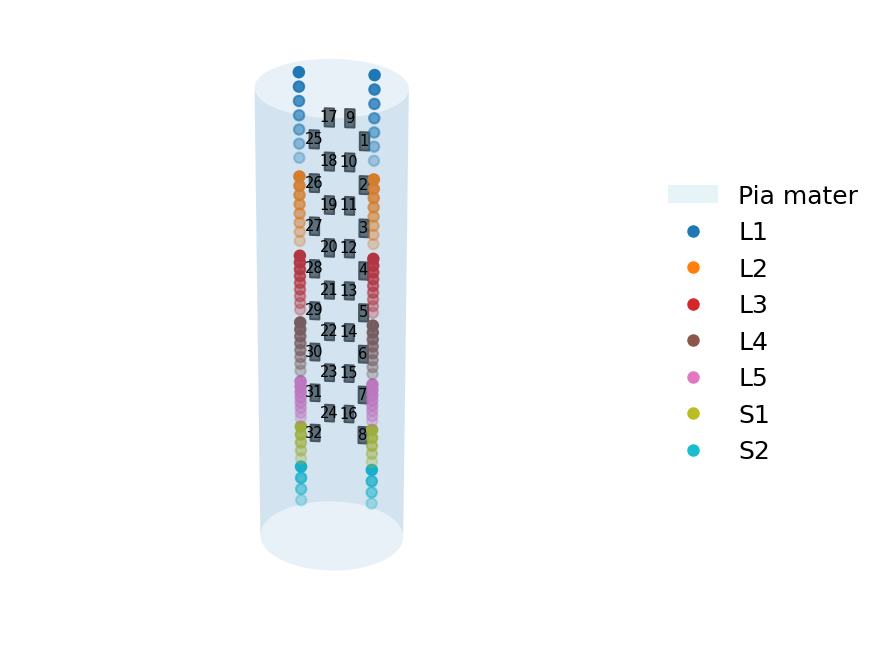

In [5]:
plot_electrical_model(rootlets=True, labels=True)

## 1.4 Computing extracellular potentials with FEM

> **Question:** How do we obtain the extracellular potential at those fiber locations?

Under the quasi-static approximation, the tissues are treated as purely conductive and endogenous biological currents are assumed negligible compared with the stimulation current. Within each tissue compartment, the extracellular potential is obtained from:

$$
\nabla\cdot\left(\sigma(\mathbf{x})\nabla V(\mathbf{x})\right)=0,
$$

with the potential fixed to zero at the external boundary of the model:

$$
V=0.
$$

The three-dimensional geometry is discretized into tetrahedral elements and solved using the **Finite Element Method (FEM)** in COMSOL Multiphysics. Each electrode is simulated independently using a **1 A reference current**. COMSOL then exports the extracellular potential, in **Volts**, at every representative sensory-fiber location.

This creates the link between the electrical field and the neural structures:
<center>
<b>electrode current → extracellular potential at each representative sensory fiber</b>
</center>

<br>

> **Why 1 A?** Because the volume conductor is linear, the absolute reference current is only used to determine the transfer coefficient between each electrode and each fiber. In this notebook, the exported values are converted from V to mV and normalized by 1000 mA, giving the LFM in **mV/mA**.


## 1.5 Building the Lead Field Matrix

> **Question:** Why do we need a Lead Field Matrix?

Repeating a FEM simulation every time the current amplitude changes would be unnecessary and slow. Because the volume conductor is assumed linear, the response to each electrode can be computed **once** and stored. The FEM solution produced by one electrode corresponds to one row of the **Lead Field Matrix (LFM)**.

For an arbitrary stimulation pattern,

$$
\mathbf{V}=\mathbf{L}\mathbf{I}
$$

where:

- $\mathbf{I}$ contains the electrode currents in **mA**;
- $\mathbf{L}$ is the LFM in **mV/mA**;
- $\mathbf{V}$ contains the extracellular potentials in **mV**.

This lead-field approach follows the computational strategy described by **Romeni et al.** [3].

### Build the Lead Field Matrix

The raw COMSOL files contain potentials in **V** obtained with a **1 A = 1000 mA** reference current. During LFM construction, `build_lfm` performs:

$$
L_{e,f}
=
\frac{V^{\mathrm{COMSOL}}_{e,f}\times1000\;\mathrm{mV/V}}
{1000\;\mathrm{mA}}.
$$

Once the LFM has been built, new electrode/current combinations can be evaluated almost instantaneously without solving the FEM problem again.


In [6]:
lfm, site_ids, fiber_coordinates, fiber_segments, fiber_rootlets, fiber_sides = build_lfm(
    raw_folder=RAW_LFM_FOLDER,
    value_column=-1,                                # COMSOL column: V (V)
    reference_current_ma=FEM_REFERENCE_CURRENT_MA,  # 1000 mA = 1 A
)

Building LFM:   0%|          | 0/32 [00:00<?, ?it/s]


Lead Field Matrix created
Electrodes: 32
Sensory fibers: 17998
Shape: (32, 17998)
Units: mV/mA


## 1.6 Binary sensory-fiber recruitment

> **Question:** When is a sensory fiber considered recruited?

A detailed hybrid model would apply the extracellular potential to a biophysical axon model and explicitly simulate membrane polarization and action-potential generation. For this hands-on, we deliberately use a simpler **binary threshold model**.

Under cathodic stimulation, a sufficiently negative extracellular potential can depolarize the membrane and trigger an action potential. To keep the model simple, however, we consider only the **magnitude** of the extracellular perturbation predicted by the LFM. A representative sensory fiber is therefore considered recruited when:

$$
|V_f| \geq V_{\mathrm{th}}.
$$

In other words, a fiber is classified as recruited whenever the magnitude of the extracellular potential exceeds a fixed threshold, regardless of its polarity.

> **Modeling assumption:** this thresholding rule is a simplified proxy for axonal recruitment and does not explicitly model membrane polarization or polarity-dependent excitability.

In [7]:
def compute_fiber_activation(
    lfm,
    site_ids,
    stimulation_sites,
    threshold_mv,
):
    lfm = np.asarray(lfm, dtype=float)
    site_ids = np.asarray(site_ids)

    if lfm.ndim != 2:
        raise ValueError("lfm must be (n_sites, n_fibers)")

    currents_ma = np.zeros(len(site_ids), dtype=float)

    for site, current_ma in stimulation_sites.items():
        idx = np.where(site_ids == int(site))[0]

        if len(idx) == 0:
            raise ValueError(f"Site {site} not found")

        currents_ma[idx[0]] = float(current_ma)

    fiber_potential_mv = currents_ma @ lfm

    fiber_activation = (
        fiber_potential_mv >= float(threshold_mv)
    ).astype(float)

    return {
        "currents_ma": currents_ma,
        "fiber_potential_mv": fiber_potential_mv,
        "fiber_activation": fiber_activation,
        "threshold_mv": float(threshold_mv),
    }

### Try one stimulation pattern

We now evaluate the current pattern defined above. At this stage we are still working only at the **electrical / sensory-fiber level**.


In [8]:
STIMULATION_SITES = {1: 1.0}   # electrode: current [mA]
FIBER_THRESHOLD_MV = 85.0

print("Stimulation sites:", STIMULATION_SITES)
print("Fiber threshold  :", FIBER_THRESHOLD_MV, "mV")

Stimulation sites: {1: 1.0}
Fiber threshold  : 85.0 mV


In [9]:
fiber_result = compute_fiber_activation(
    lfm=lfm,
    site_ids=site_ids,
    stimulation_sites=STIMULATION_SITES,
    threshold_mv=FIBER_THRESHOLD_MV,
)

fiber_potential_mv = fiber_result["fiber_potential_mv"]
fiber_activation = fiber_result["fiber_activation"]

print("Active fibers   :", int(fiber_activation.sum()), "/", len(fiber_activation))
print("Active fraction :", f"{fiber_activation.mean():.3f}")


# ------------------------------------------------------------
# Fiber-level results
# ------------------------------------------------------------

fiber_activation_df = pd.DataFrame({
    "segment": fiber_segments,
    "rootlet": fiber_rootlets,
    "side": fiber_sides,
    "potential_mv": fiber_potential_mv,
    "abs_potential_mv": np.abs(fiber_potential_mv),
    "active": fiber_activation.astype(int),
})


# ------------------------------------------------------------
# Aggregate fibers within each dorsal rootlet
# ------------------------------------------------------------

rootlet_activation_df = (
    fiber_activation_df
    .groupby(["segment", "rootlet", "side"], as_index=False)
    .agg(
        n_fibers=("active", "size"),
        recruited_fibers=("active", "sum"),
        recruitment=("active", "mean"),
        peak_potential_mv=("abs_potential_mv", "max"),
    )
)

rootlet_activation_df["target"] = (
    rootlet_activation_df["segment"]
    + "_"
    + rootlet_activation_df["rootlet"].astype(str)
    + "_"
    + rootlet_activation_df["side"]
)

rootlet_activation_df = (
    rootlet_activation_df
    .sort_values(
        ["side", "segment", "rootlet"]
    )
    .reset_index(drop=True)
)

display(rootlet_activation_df)

Active fibers   : 710 / 17998
Active fraction : 0.039


,segment,rootlet,side,n_fibers,recruited_fibers,recruitment,peak_potential_mv,target
0,L1,1,left,119,0,0.0,80.068253,L1_1_left
1,L1,2,left,119,0,0.0,82.432831,L1_2_left
2,L1,3,left,119,119,1.0,86.999832,L1_3_left
3,L1,4,left,119,119,1.0,94.490226,L1_4_left
4,L1,5,left,119,119,1.0,104.921090,L1_5_left
...,...,...,...,...,...,...,...,...
93,S1,5,right,400,0,0.0,22.253523,S1_5_right
94,S2,1,right,234,0,0.0,21.984905,S2_1_right
95,S2,2,right,234,0,0.0,21.738717,S2_2_right
96,S2,3,right,234,0,0.0,21.578202,S2_3_right


The figure below shows the extracellular potentials of individual sensory fibers grouped by dorsal rootlet. Each point represents one representative fiber, while the activation threshold separates recruited from non-recruited fibers.

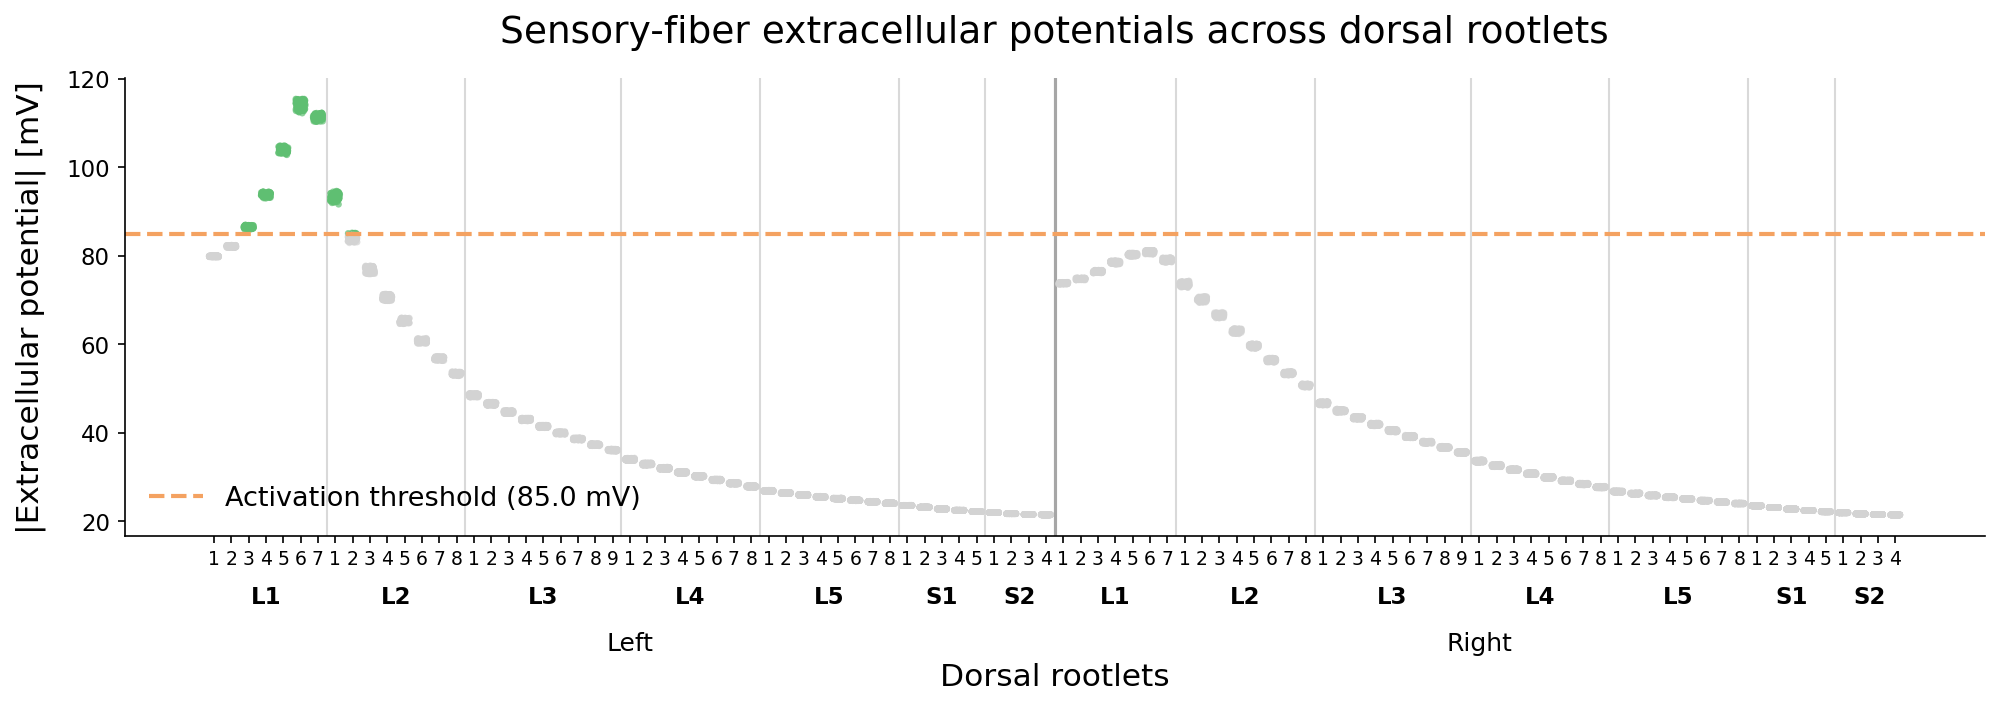

In [10]:
plot_rootlet_extracellular_potentials(
    fiber_activation_df=fiber_activation_df,
    threshold_mv=FIBER_THRESHOLD_MV,
)

## 1.7 From recruited fibers to spinal-segment recruitment

> **Question:** How do recruited sensory fibers become spinal-segment recruitment?

The recruited sensory fibers are first grouped within their corresponding **dorsal rootlets**. The recruitment of each rootlet is defined as the fraction of its representative fibers that exceed the activation threshold.

Rootlets belonging to the same spinal segment are then combined to obtain a single recruitment value for each lumbosacral segment (**L1–S2**).

For simplicity, we assume

$$
\mathrm{Ia\ fraction}=1.0,
$$

meaning that all representative sensory fibers contribute directly to the Ia-recruitment estimate.

> **Modeling assumption:** segment recruitment is approximated by the average recruitment of the representative sensory fibers belonging to that segment.

In [11]:
SEGMENT_NAMES = ["L1", "L2", "L3", "L4", "L5", "S1", "S2"]

segments = [
    {"number_v": 5384, "number_d": 16820, "n_rootlets": 7, "diameter": 0.28},
    {"number_v": 7374, "number_d": 18651, "n_rootlets": 8, "diameter": 0.35},
    {"number_v": 9169, "number_d": 26191, "n_rootlets": 9, "diameter": 0.40},
    {"number_v": 7878, "number_d": 31175, "n_rootlets": 8, "diameter": 0.52},
    {"number_v": 8657, "number_d": 34455, "n_rootlets": 8, "diameter": 0.49},
    {"number_v": 8253, "number_d": 41543, "n_rootlets": 5, "diameter": 0.23},
    {"number_v": 4766, "number_d": 18642, "n_rootlets": 4, "diameter": 0.06},
]

segments_df = pd.DataFrame(segments, index=SEGMENT_NAMES)

# Hands-on simplification: all modeled sensory fibers are treated as the Ia population.
percentage_Ia_sf = 1.0

segments_df["n_Ia"] = segments_df["number_d"] * percentage_Ia_sf
segments_df["Ia_per_rootlet"] = segments_df["n_Ia"] / segments_df["n_rootlets"]

display(segments_df)

,number_v,number_d,n_rootlets,diameter,n_Ia,Ia_per_rootlet
L1,5384,16820,7,0.28,16820.0,2402.857143
L2,7374,18651,8,0.35,18651.0,2331.375000
L3,9169,26191,9,0.40,26191.0,2910.111111
L4,7878,31175,8,0.52,31175.0,3896.875000
L5,8657,34455,8,0.49,34455.0,4306.875000
S1,8253,41543,5,0.23,41543.0,8308.600000
S2,4766,18642,4,0.06,18642.0,4660.500000


The recruited sensory fibers are now grouped by spinal segment. For each segment and body side, recruitment is computed as the fraction of representative sensory fibers exceeding the activation threshold.

In [12]:
# Aggregate recruited sensory fibers by spinal segment
segment_recruitment_df = (
    fiber_activation_df
    .groupby(["side", "segment"], as_index=False)
    .agg(
        n_fibers=("active", "size"),
        recruited_fibers=("active", "sum"),
        recruitment=("active", "mean"),
    )
)

segment_recruitment_df["recruitment_pct"] = (
    100 * segment_recruitment_df["recruitment"]
)

display(segment_recruitment_df)

,side,segment,n_fibers,recruited_fibers,recruitment,recruitment_pct
0,left,L1,833,595,0.714286,71.428571
1,left,L2,856,115,0.134346,13.434579
2,left,L3,1278,0,0.000000,0.000000
3,left,L4,1496,0,0.000000,0.000000
4,left,L5,1600,0,0.000000,0.000000
5,left,S1,2000,0,0.000000,0.000000
6,left,S2,936,0,0.000000,0.000000
7,right,L1,833,0,0.000000,0.000000
8,right,L2,856,0,0.000000,0.000000
9,right,L3,1278,0,0.000000,0.000000


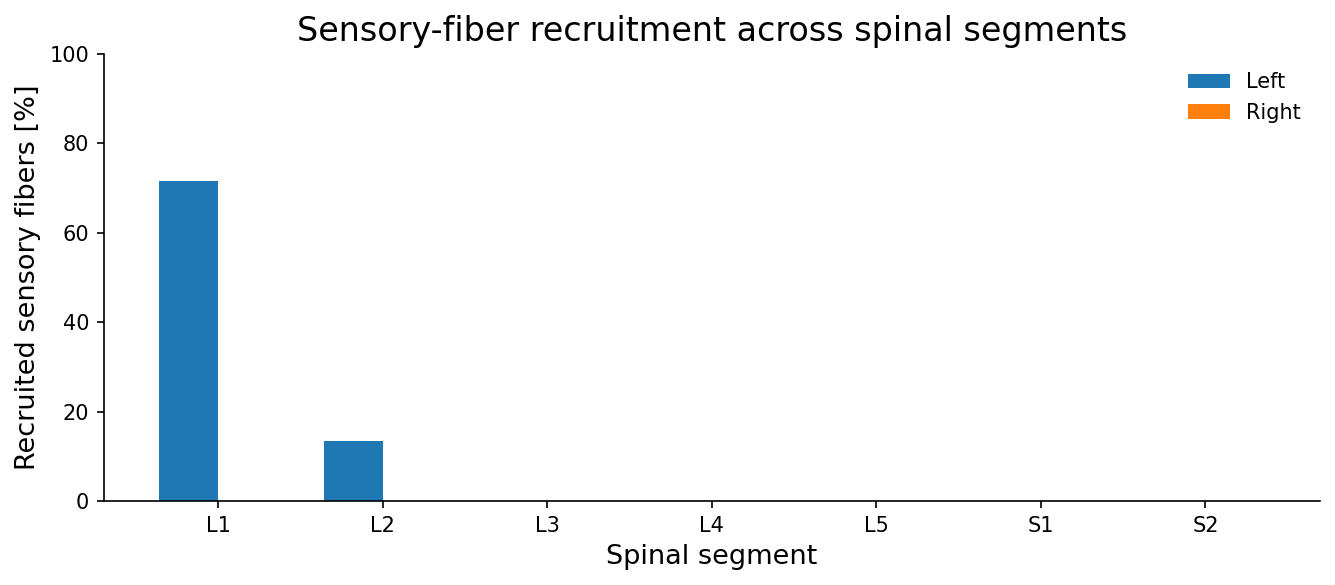

In [13]:
fig, ax = plt.subplots(figsize=(9, 4), dpi=150)

x = np.arange(len(SEGMENT_NAMES))
width = 0.36

for offset, side in zip([-width / 2, width / 2], ["left", "right"]):
    values = (
        segment_recruitment_df
        .query("side == @side")
        .set_index("segment")
        .reindex(SEGMENT_NAMES)["recruitment_pct"]
        .fillna(0)
        .values
    )

    ax.bar(
        x + offset,
        values,
        width,
        label=side.capitalize(),
    )

ax.set_xticks(x)
ax.set_xticklabels(SEGMENT_NAMES)

ax.set_ylim(0, 100)
ax.set_xlabel("Spinal segment", fontsize=13)
ax.set_ylabel("Recruited sensory fibers [%]", fontsize=13)
ax.set_title("Sensory-fiber recruitment across spinal segments", fontsize=16)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

### ✅ Take-home message — section 1

The electrical model can rapidly estimate sensory-fiber recruitment for any stimulation pattern by combining precomputed FEM solutions through the Lead Field Matrix.


# 2. From muscle recruitment to muscle activation

> **Scientific question:** How can recruited sensory fibers and spinal segments be translated into muscle activation?

### Roadmap

<center>
<b> sensory-fiber recruitment → muscle recruitment → muscle excitation → first-order activation dynamics → muscle activation </b>
</center>


## 2.1 Modeling assumptions

To keep the hands-on transparent and computationally efficient, we use a deliberately simplified neural-to-muscle mapping. Three major simplifications are used:

1. **No explicit biophysical neuron model.**  
   Ia afferents and spinal motoneurons are not simulated using multicompartment neuronal models. Consequently, stimulation **site and current amplitude** are represented explicitly, while pulse width and stimulation frequency are not explicitly modeled at the neuronal level.

   > **Interested in more detailed neural models?**  
   > Biophysical models can explicitly represent membrane dynamics, ion channels and action-potential propagation in sensory axons and motoneurons. A widely used simulator is **NEURON**. See the official documentation:  
   > https://nrn.readthedocs.io/en/latest/

2. **Direct Ia-to-motoneuron recruitment approximation.**  
   For each muscle, the recruitment of its Ia afferents is assumed to directly estimate the recruitment of the motoneuron pool innervating the same muscle:

$$
\%\,Ia_{\mathrm{m,recruited}}
\approx
\%\,MN_{\mathrm{m,recruited}}
$$

3. **Tetanic response assumption.**  
   We assume a stimulation frequency high enough to produce a tetanic muscle response, so motoneuron recruitment is used directly as the amplitude of muscle excitation.

<br>
Therefore, the simplified hands-on pipeline is

$$
R_{\mathrm{Ia}}
\rightarrow
R_{\mathrm{MN}}
\rightarrow
u_{\mathrm{muscle}}.
$$




## 2.2 From spinal segments to muscle-specific recruitment

> **Question:** Which muscles are associated with the recruited spinal segments?

Until this point, the model has only told us **where neural recruitment occurs**. We now introduce the anatomical bridge between the spinal cord and the muscles.
The segment-to-muscle mapping is based on the human myotomal distributions reported by **Schirmer et al. (2011)** [2]. The table below describes the relative contribution of each lumbosacral segment to the lower-limb muscle groups considered in the hands-on.

The `None` row represents the fraction of a segment that is not assigned to one of the modeled muscle groups.

In [14]:
muscle_map = {
    "Muscle": [
        "Iliopsoas",
        "Adductor",
        "Adductor magnus",
        "Quadriceps",
        "Biceps femoris",
        "Gastrocnemius",
        "Tibialis anterior",
        "Extensor hallucis",
        "None",
    ],
    "L1": [42.85, 42.85, 0, 14.3, 0, 0, 0, 0, 0],
    "L2": [28.0, 6.1, 19.5, 32.9, 0, 0, 0, 4.9, 8.6],
    "L3": [16.0, 8.0, 21.2, 44.3, 1.9, 1.4, 4.2, 0.5, 2.5],
    "L4": [5.6, 1.3, 4.3, 29.0, 6.9, 11.2, 35.6, 2.3, 3.8],
    "L5": [0.9, 0, 1.5, 0.6, 12.1, 23.9, 44.5, 9.7, 6.8],
    "S1": [1.3, 0, 2.0, 0, 8.7, 53.7, 19.5, 11.4, 3.4],
    "S2": [0, 0, 0, 0, 0, 50.0, 0, 50.0, 0],
}

myotome_df = pd.DataFrame(muscle_map).set_index("Muscle")

display(myotome_df)

,L1,L2,L3,L4,L5,S1,S2
Muscle,,,,,,,
Iliopsoas,42.85,28.0,16.0,5.6,0.9,1.3,0.0
Adductor,42.85,6.1,8.0,1.3,0.0,0.0,0.0
Adductor magnus,0.00,19.5,21.2,4.3,1.5,2.0,0.0
Quadriceps,14.30,32.9,44.3,29.0,0.6,0.0,0.0
Biceps femoris,0.00,0.0,1.9,6.9,12.1,8.7,0.0
Gastrocnemius,0.00,0.0,1.4,11.2,23.9,53.7,50.0
Tibialis anterior,0.00,0.0,4.2,35.6,44.5,19.5,0.0
Extensor hallucis,0.00,4.9,0.5,2.3,9.7,11.4,50.0
None,0.00,8.6,2.5,3.8,6.8,3.4,0.0


### Map segmental recruitment to muscles

The myotomal percentages are used as fixed anatomical weights. For each side, segment-level recruitment is combined with the Schirmer weights to estimate muscle-specific recruitment.

In [15]:
def compute_muscle_recruitment(segment_recruitment_df, segments_df, myotome_df):
    results = []
    for side in ['left', 'right']:
        side_df = segment_recruitment_df[segment_recruitment_df['side'] == side].set_index('segment')
        for muscle in myotome_df.index:
            if muscle == 'None':
                continue
            numerator = 0.0
            denominator = 0.0
            for segment in SEGMENT_NAMES:
                weight = float(myotome_df.loc[muscle, segment]) / 100.0
                if weight == 0:
                    continue
                n_Ia = float(segments_df.loc[segment, 'n_Ia'])
                recruitment = float(side_df.loc[segment, 'recruitment'])
                numerator += n_Ia * recruitment * weight
                denominator += n_Ia * weight
            muscle_recruitment = numerator / denominator if denominator > 0 else 0.0
            results.append({'side': side, 'muscle': muscle, 'muscle_recruitment': float(np.clip(muscle_recruitment, 0.0, 1.0))})
    return pd.DataFrame(results)

muscle_recruitment_df = compute_muscle_recruitment(
    segment_recruitment_df=segment_recruitment_df,
    segments_df=segments_df,
    myotome_df=myotome_df,
)

display(muscle_recruitment_df)

,side,muscle,muscle_recruitment
0,left,Iliopsoas,0.304416
1,left,Adductor,0.488765
2,left,Adductor magnus,0.041137
3,left,Quadriceps,0.086502
4,left,Biceps femoris,0.000000
5,left,Gastrocnemius,0.000000
6,left,Tibialis anterior,0.000000
7,left,Extensor hallucis,0.006408
8,right,Iliopsoas,0.000000
9,right,Adductor,0.000000


The segment-level recruitment is now converted into muscle recruitment using the **Schirmer myotomal map**. Each muscle receives a weighted contribution from the spinal segments that innervate it.

The figure below shows the predicted recruitment of each muscle group on the left and right sides.

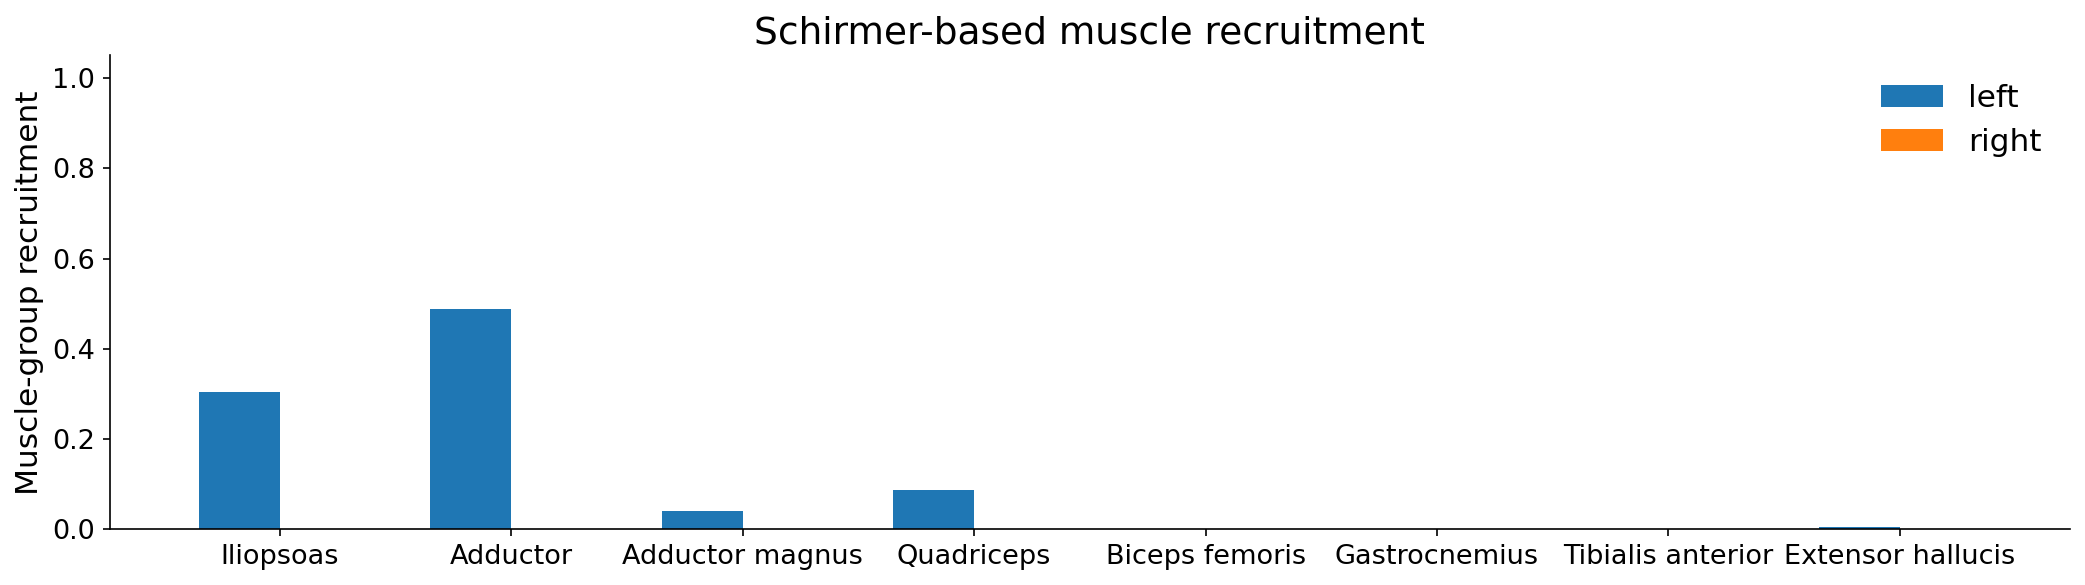

In [16]:
fig, ax = plt.subplots(figsize=(14, 4), dpi=150)

muscles = [m for m in myotome_df.index if m != "None"]
x = np.arange(len(muscles))
width = 0.35

for offset, side in [(-width / 2, "left"), (width / 2, "right")]:
    side_df = muscle_recruitment_df[muscle_recruitment_df["side"] == side].set_index("muscle")
    values = [float(side_df.loc[m, "muscle_recruitment"]) for m in muscles]
    ax.bar(x + offset, values, width=width, label=side)

ax.set_xticks(x)
ax.set_xticklabels(muscles, rotation=0, ha="center")
ax.set_ylabel("Muscle-group recruitment", fontsize=15)
ax.set_title("Schirmer-based muscle recruitment", fontsize=18)
ax.set_ylim(0, 1.05)
ax.tick_params("both", labelsize=13)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=15)
plt.tight_layout()
plt.show()

## 2.3 Introducing the musculoskeletal model

> **Question:** How can predicted muscle recruitment be transformed into movement?

So far, the pipeline has estimated **which muscle groups are recruited** by a given epidural stimulation protocol. However, muscle recruitment alone does not indicate how the limb will move, because movement also depends on musculoskeletal geometry, muscle-tendon mechanics, joint constraints, and the interaction between muscles.

To predict the resulting movement, we use a **MuJoCo neuromusculoskeletal model** of the lower limb. The model includes the skeletal geometry, joint kinematics, and muscle-tendon units, allowing muscle recruitment to generate muscle forces that produce joint torques and, through forward dynamics, limb motion.

The muscle recruitment estimated in the previous section therefore becomes the input to the musculoskeletal model, bridging the gap between **neural activation** and **predicted joint kinematics**.

In [17]:
# Load the MuJoCo model
model, mj_data = load_mujoco_model(MODEL_XML)

# Build the mapping between myotomal muscle groups and MuJoCo actuators
actuator_names = get_actuator_names(model)
actuator_mapping_df = create_actuator_mapping_table(
    actuator_names
)

# Assign muscle recruitment to each actuator
actuator_recruitment = map_muscle_recruitment_to_actuators(
    muscle_recruitment_df=muscle_recruitment_df,
    actuator_mapping_df=actuator_mapping_df,
    missing_value=0.0,
)

actuator_mapping_df["recruitment"] = actuator_recruitment

print(f"Muscle groups : {muscle_recruitment_df['muscle'].nunique()}")
print(f"MuJoCo actuators: {model.nu}")
print(f"Mapped actuators: {actuator_mapping_df['muscle_group'].notna().sum()}")

display(
    actuator_mapping_df[
        ["actuator", "side", "muscle_group", "recruitment"]
    ]
)

MuJoCo model loaded
-----------------------------
nq: 28
nv: 28
nu: 80
na: 80
timestep: 0.001
Muscle groups : 8
MuJoCo actuators: 80
Mapped actuators: 42


,actuator,side,muscle_group,recruitment
0,addbrev_r,right,Adductor,0.000000
1,addlong_r,right,Adductor,0.000000
2,addmagDist_r,right,Adductor magnus,0.000000
3,addmagIsch_r,right,Adductor magnus,0.000000
4,addmagMid_r,right,Adductor magnus,0.000000
...,...,...,...,...
75,tibant_l,left,Tibialis anterior,0.000000
76,tibpost_l,left,NaN,0.000000
77,vasint_l,left,Quadriceps,0.086502
78,vaslat_l,left,Quadriceps,0.086502


## 2.4 Muscle activation dynamics

> **Question:** Why is muscle recruitment not applied instantaneously?

Neural excitation changes rapidly, but muscle force does not. Excitation-contraction coupling introduces a delay in force development, while relaxation is typically slower than activation. This behavior is commonly represented using a first-order activation dynamic in Hill-type muscle models [4,5]:

$$
\frac{da}{dt}
=
\frac{u(t)-a(t)}{\tau},
$$

where:

- $u(t)$ is muscle excitation;
- $a(t)$ is muscle activation;
- $\tau$ is the activation or deactivation time constant.

Different time constants are used for activation and relaxation, reflecting the faster rise and slower decay of muscle activation. In this hands-on we use the commonly adopted values of **10 ms** for activation and **40 ms** for deactivation [6].

In [18]:
TAU_ACTIVATION_S = 0.01
TAU_DEACTIVATION_S = 0.04
PRE_REST_S = 5.0
STIMULATION_DURATION_S = 2.0
POST_REST_S = 3.0

def first_order_activation(u, dt, tau_activation=TAU_ACTIVATION_S, tau_deactivation=TAU_DEACTIVATION_S, a0=0.0):
    u = np.asarray(u, dtype=float)
    a = np.zeros_like(u)
    a[0] = float(a0)
    for i in range(1, len(u)):
        tau = tau_activation if u[i] >= a[i - 1] else tau_deactivation
        a[i] = a[i - 1] + dt * (u[i] - a[i - 1]) / tau
    return np.clip(a, 0.0, 1.0)

def generate_mujoco_activation_timeseries(actuator_recruitment, model, duration_s=STIMULATION_DURATION_S, tau_activation=TAU_ACTIVATION_S, tau_deactivation=TAU_DEACTIVATION_S, pre_rest_s=PRE_REST_S, post_rest_s=POST_REST_S):
    dt = float(model.opt.timestep)
    r = np.clip(np.asarray(actuator_recruitment, dtype=float), 0.0, 1.0)
    n_pre = int(np.round(pre_rest_s / dt))
    n_stim = int(np.round(duration_s / dt))
    n_post = int(np.round(post_rest_s / dt))
    n_steps = n_pre + n_stim + n_post
    t = np.arange(n_steps) * dt
    excitation = np.zeros((n_steps, len(r)), dtype=float)
    activations = np.zeros_like(excitation)
    for j in range(len(r)):
        u = np.zeros(n_steps)
        u[n_pre:n_pre + n_stim] = r[j]
        excitation[:, j] = u
        activations[:, j] = first_order_activation(u=u, dt=dt, tau_activation=tau_activation, tau_deactivation=tau_deactivation)
    return (t, excitation, activations, n_pre, n_pre + n_stim)

The example below applies a square excitation pulse and shows how the first-order model converts it into a smoother activation trajectory.

This is the temporal signal that will drive the MuJoCo actuators.

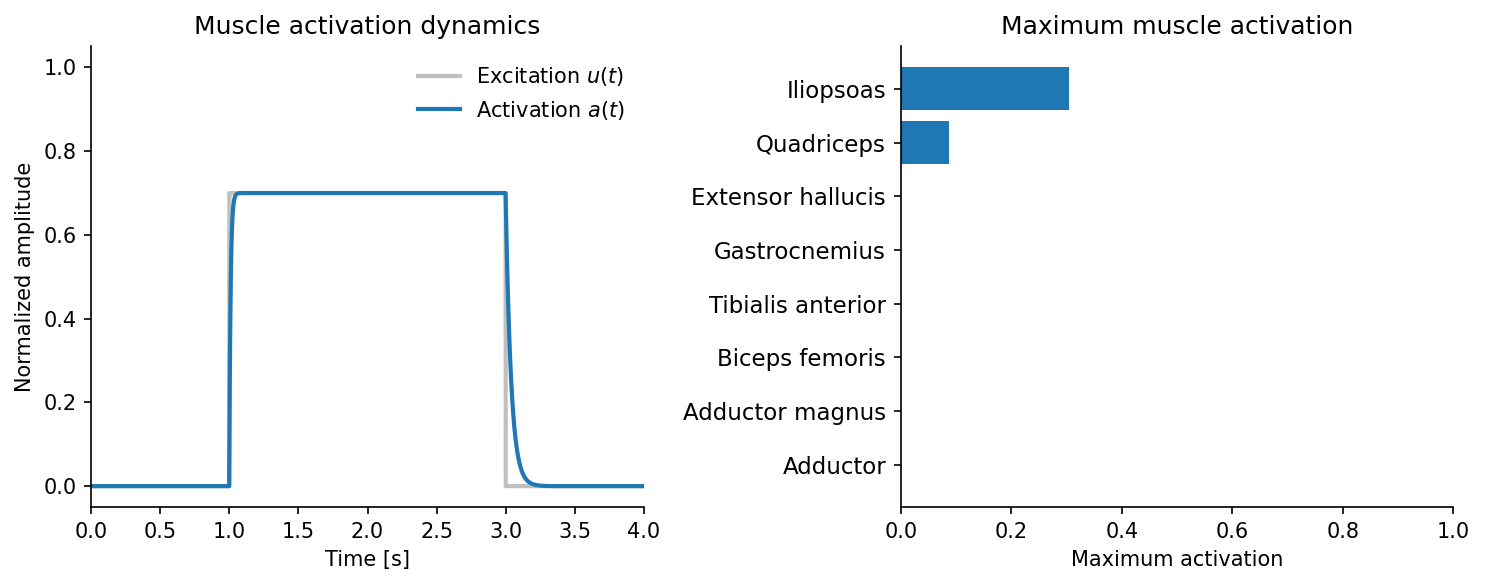

In [19]:
t, excitation, mujoco_activations, stim_start_idx, stim_end_idx = (
    generate_mujoco_activation_timeseries(
        actuator_recruitment=actuator_recruitment,
        model=model,
        duration_s=STIMULATION_DURATION_S,
        pre_rest_s=PRE_REST_S,
        post_rest_s=POST_REST_S,
    )
)

# ------------------------------------------------------------
# Illustrative activation-dynamics example
# ------------------------------------------------------------

u_demo = 0.7 * ((t >= 1.0) & (t < 3.0)).astype(float)

a_demo = np.zeros_like(t)

for i in range(1, len(t)):
    dt = t[i] - t[i - 1]

    tau = (
        TAU_ACTIVATION_S
        if u_demo[i] > a_demo[i - 1]
        else TAU_DEACTIVATION_S
    )

    a_demo[i] = (
        a_demo[i - 1]
        + dt * (u_demo[i] - a_demo[i - 1]) / tau
    )


MUSCLE_ORDER = [
    "Iliopsoas",
    "Quadriceps",
    "Adductor",
    "Adductor magnus",
    "Biceps femoris",
    "Tibialis anterior",
    "Gastrocnemius",
    "Extensor hallucis",
]

MUSCLE_MAP = {
    "Iliopsoas": ["iliopsoas", "psoas"],
    "Quadriceps": ["rect_fem", "vas"],
    "Adductor": ["add_long", "add_brev"],
    "Adductor magnus": ["add_mag"],
    "Biceps femoris": ["bifem"],
    "Tibialis anterior": ["tib_ant"],
    "Gastrocnemius": ["gas"],
    "Extensor hallucis": ["ext_hal"],
}

muscle_max = []

for muscle in MUSCLE_ORDER:
    idx = [
        i
        for i, name in enumerate(actuator_names)
        if any(k in name.lower() for k in MUSCLE_MAP[muscle])
    ]

    muscle_max.append(
        mujoco_activations[:, idx].max()
        if idx
        else 0.0
    )


fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

# Activation-dynamics example
ax[0].plot(
    t,
    u_demo,
    lw=2,
    color="silver",
    label="Excitation $u(t)$",
)

ax[0].plot(
    t,
    a_demo,
    lw=2,
    label="Activation $a(t)$",
)

ax[0].set(
    xlabel="Time [s]",
    ylabel="Normalized amplitude",
    title="Muscle activation dynamics",
)

ax[0].set_xlim(0, 4)
ax[0].set_ylim(-0.05, 1.05)
ax[0].legend(frameon=False)

# Maximum activation across muscle groups
order = np.argsort(muscle_max)

ax[1].barh(
    np.array(MUSCLE_ORDER)[order],
    np.array(muscle_max)[order],
)

ax[1].set(
    xlabel="Maximum activation",
    title="Maximum muscle activation",
)

ax[1].set_xlim(0, 1)
ax[1].tick_params(axis="y", labelsize=11)

for axis in ax:
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### ✅ Take-home message — section 2

The recruited sensory fibers are transformed into muscle-specific excitation through simplified spinal and myotomal recruitment models.

# 3. From muscle activation to movement

> **Scientific question:** What joint movement is generated by the recruited muscles?

MuJoCo performs forward dynamics using the time-varying actuator commands generated in the previous section.

### Roadmap

<center>
<b> muscle activation → muscle forces and joint torques → multibody forward dynamics → joint kinematics </b>
</center>

## 3.1 Forward dynamics

Once the time-varying muscle activations have been computed, they are applied to the MuJoCo musculoskeletal model as actuator inputs.

Forward dynamics solves the equations of motion of the system over time: at each simulation step, the muscle actuators generate forces, these forces produce joint torques through the musculoskeletal geometry, and the resulting accelerations update the joint velocities and positions.

In other words, the simulation propagates the system forward in time:

<center>
<b> muscle activation → muscle forces → joint torque → joint acceleration → joint motion</b>
</center>

We first run the complete pipeline for the stimulation pattern already analyzed above. For this single demonstration, the forward-dynamics progress bar is kept visible so participants can see the simulation running.

In [20]:
RUN_FORWARD_DYNAMICS = True
GENERATE_VIDEO = True

if RUN_FORWARD_DYNAMICS:
    all_qpos, all_qvel, all_ctrl, all_act, video_path = forward_dynamics(
        activations=mujoco_activations,
        model=model,
        data=mj_data,
        output_folder=OUTPUT_FOLDER,
        gen_video=GENERATE_VIDEO,
        pre_rest_s=5.0,
        video_start_before_activation_s=1.0,
        show_progress=True,
    )

    print("Forward dynamics completed")
    print("qpos:", all_qpos.shape)
    print("qvel:", all_qvel.shape)
    print("ctrl:", all_ctrl.shape)
    print("act :", all_act.shape)
    print("video:", video_path)

Forward dynamics:   0%|          | 0/10000 [00:00<?, ?it/s]

Forward dynamics completed
qpos: (10000, 28)
qvel: (10000, 28)
ctrl: (10000, 80)
act : (10000, 80)
video: /Users/nicolegiannotto/Desktop/PhD/Conferenze/IFES26/code/results/forward_dynamics.mp4


## 3.2 Compare different stimulation sites

We now keep the stimulation amplitude fixed while activating four different electrodes, one at a time.

This simple comparison illustrates how changing only the **stimulation site** modifies the spatial pattern of sensory-fiber recruitment, the resulting muscle activation, and ultimately the predicted movement. In particular, it allows us to observe differences in **laterality**, **symmetry of muscle recruitment**, and the joint kinematics generated by each stimulation pattern.

In [21]:
SIMULATION_DURATION_S = STIMULATION_DURATION_S
GENERATE_PATTERN_VIDEOS = False
STIMULATION_PATTERNS = {
    "Pattern 1": {"sites": {1: 1.0}},
    "Pattern 2": {"sites": {9: 1.0}},
    "Pattern 3": {"sites": {17: 1.0}},
    "Pattern 4": {"sites": {25: 1.0}},
}

In [22]:
def get_hinge_joint_angles(model, all_qpos):
    all_qpos = np.asarray(all_qpos, dtype=float)
    out = {}

    for jid in range(model.njnt):
        if model.jnt_type[jid] != mujoco.mjtJoint.mjJNT_HINGE:
            continue

        name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, jid)
        name = name or f"joint_{jid}"
        out[name] = np.rad2deg(all_qpos[:, model.jnt_qposadr[jid]])

    return out


def summarize_joint_angles(joint_angles, time, analysis_start_s, analysis_end_s=None):
    time = np.asarray(time, dtype=float)
    pre_idx = max(0, np.searchsorted(time, analysis_start_s) - 1)

    rows = []
    for name, angle in joint_angles.items():
        angle = np.asarray(angle, dtype=float)
        initial = float(angle[pre_idx])

        mask = time >= analysis_start_s
        if analysis_end_s is not None:
            mask &= time <= analysis_end_s

        values = angle[mask]
        if values.size == 0:
            continue

        rows.append({
            "joint": name,
            "initial_deg": initial,
            "min_deg": float(values.min()),
            "max_deg": float(values.max()),
            "max_excursion_deg": float(np.max(np.abs(values - initial))),
        })

    return pd.DataFrame(rows)


def compute_segment_recruitment(fiber_activation_df):
    return (
        fiber_activation_df
        .groupby(["side", "segment"], as_index=False)
        .agg(
            n_fibers=("active", "size"),
            recruited_fibers=("active", "sum"),
            recruitment=("active", "mean"),
        )
    )


def run_stimulation_pattern(
    pattern_name,
    pattern,
    lfm,
    site_ids,
    fiber_segments,
    fiber_rootlets,
    fiber_sides,
    segments_df,
    myotome_df,
    model,
    data,
    actuator_mapping_df,
    output_folder,
    threshold_mv=FIBER_THRESHOLD_MV,
    simulation_duration_s=STIMULATION_DURATION_S,
    pre_rest_s=PRE_REST_S,
    post_rest_s=POST_REST_S,
    gen_video=False,
    show_fd_progress=False,
):
    print(f"\n{'=' * 70}\nRUNNING: {pattern_name}\n{'=' * 70}")

    fiber_result = compute_fiber_activation(
        lfm=lfm,
        site_ids=site_ids,
        stimulation_sites=pattern["sites"],
        threshold_mv=threshold_mv,
    )

    fiber_activation = fiber_result["fiber_activation"]
    fiber_potential_mv = fiber_result["fiber_potential_mv"]

    fiber_df = pd.DataFrame({
        "segment": fiber_segments,
        "rootlet": fiber_rootlets,
        "side": fiber_sides,
        "potential_mv": fiber_potential_mv,
        "abs_potential_mv": np.abs(fiber_potential_mv),
        "active": fiber_activation.astype(int),
    })

    segment_df = compute_segment_recruitment(fiber_df)

    muscle_df = compute_muscle_recruitment(
        segment_recruitment_df=segment_df,
        segments_df=segments_df,
        myotome_df=myotome_df,
    )

    actuator_recruitment = map_muscle_recruitment_to_actuators(
        muscle_recruitment_df=muscle_df,
        actuator_mapping_df=actuator_mapping_df,
        missing_value=0.0,
    )

    time, excitation, activations, s0, s1 = generate_mujoco_activation_timeseries(
        actuator_recruitment=actuator_recruitment,
        model=model,
        duration_s=simulation_duration_s,
        pre_rest_s=pre_rest_s,
        post_rest_s=post_rest_s,
    )

    folder = Path(output_folder) / "pattern_comparison" / pattern_name.replace(" ", "_")

    qpos, qvel, ctrl, act, video_path = forward_dynamics(
        activations=activations,
        model=model,
        data=data,
        output_folder=folder,
        gen_video=gen_video,
        pre_rest_s=pre_rest_s,
        video_start_before_activation_s=1.0,
        show_progress=show_fd_progress,
    )

    joint_angles = get_hinge_joint_angles(model, qpos)
    joint_summary = summarize_joint_angles(
        joint_angles,
        time,
        analysis_start_s=float(time[s0]),
        analysis_end_s=float(time[-1]),
    )

    print(f"Active fibers         : {int(fiber_activation.sum())}/{len(fiber_activation)}")
    print(f"Active fraction       : {fiber_activation.mean():.3f}")
    print(f"Max muscle recruitment: {muscle_df['muscle_recruitment'].max():.3f}")

    return {
        "pattern": pattern_name,
        "fiber_result": fiber_result,
        "fibers": fiber_df,
        "segments": segment_df,
        "muscles": muscle_df,
        "actuator_recruitment": actuator_recruitment,
        "time": time,
        "excitation": excitation,
        "activations": activations,
        "stim_start_idx": s0,
        "stim_end_idx": s1,
        "qpos": qpos,
        "qvel": qvel,
        "ctrl": ctrl,
        "act": act,
        "joint_angles": joint_angles,
        "joint_summary": joint_summary,
        "video_path": video_path,
    }

In [23]:
PATTERN_RESULTS = {}

for pattern_name, pattern in STIMULATION_PATTERNS.items():

    PATTERN_RESULTS[pattern_name] = run_stimulation_pattern(
        pattern_name=pattern_name,
        pattern=pattern,
        lfm=lfm,
        site_ids=site_ids,
        fiber_segments=fiber_segments,
        fiber_rootlets=fiber_rootlets,
        fiber_sides=fiber_sides,
        segments_df=segments_df,
        myotome_df=myotome_df,
        model=model,
        data=mj_data,
        actuator_mapping_df=actuator_mapping_df,
        output_folder=OUTPUT_FOLDER,
        threshold_mv=FIBER_THRESHOLD_MV,
        gen_video=GENERATE_PATTERN_VIDEOS,
        show_fd_progress=False,
    )

print("\n✓ All stimulation patterns completed.")


RUNNING: Pattern 1
Active fibers         : 710/17998
Active fraction       : 0.039
Max muscle recruitment: 0.489

RUNNING: Pattern 2
Active fibers         : 1547/17998
Active fraction       : 0.086
Max muscle recruitment: 0.665

RUNNING: Pattern 3
Active fibers         : 1547/17998
Active fraction       : 0.086
Max muscle recruitment: 0.665

RUNNING: Pattern 4
Active fibers         : 712/17998
Active fraction       : 0.040
Max muscle recruitment: 0.489

✓ All stimulation patterns completed.


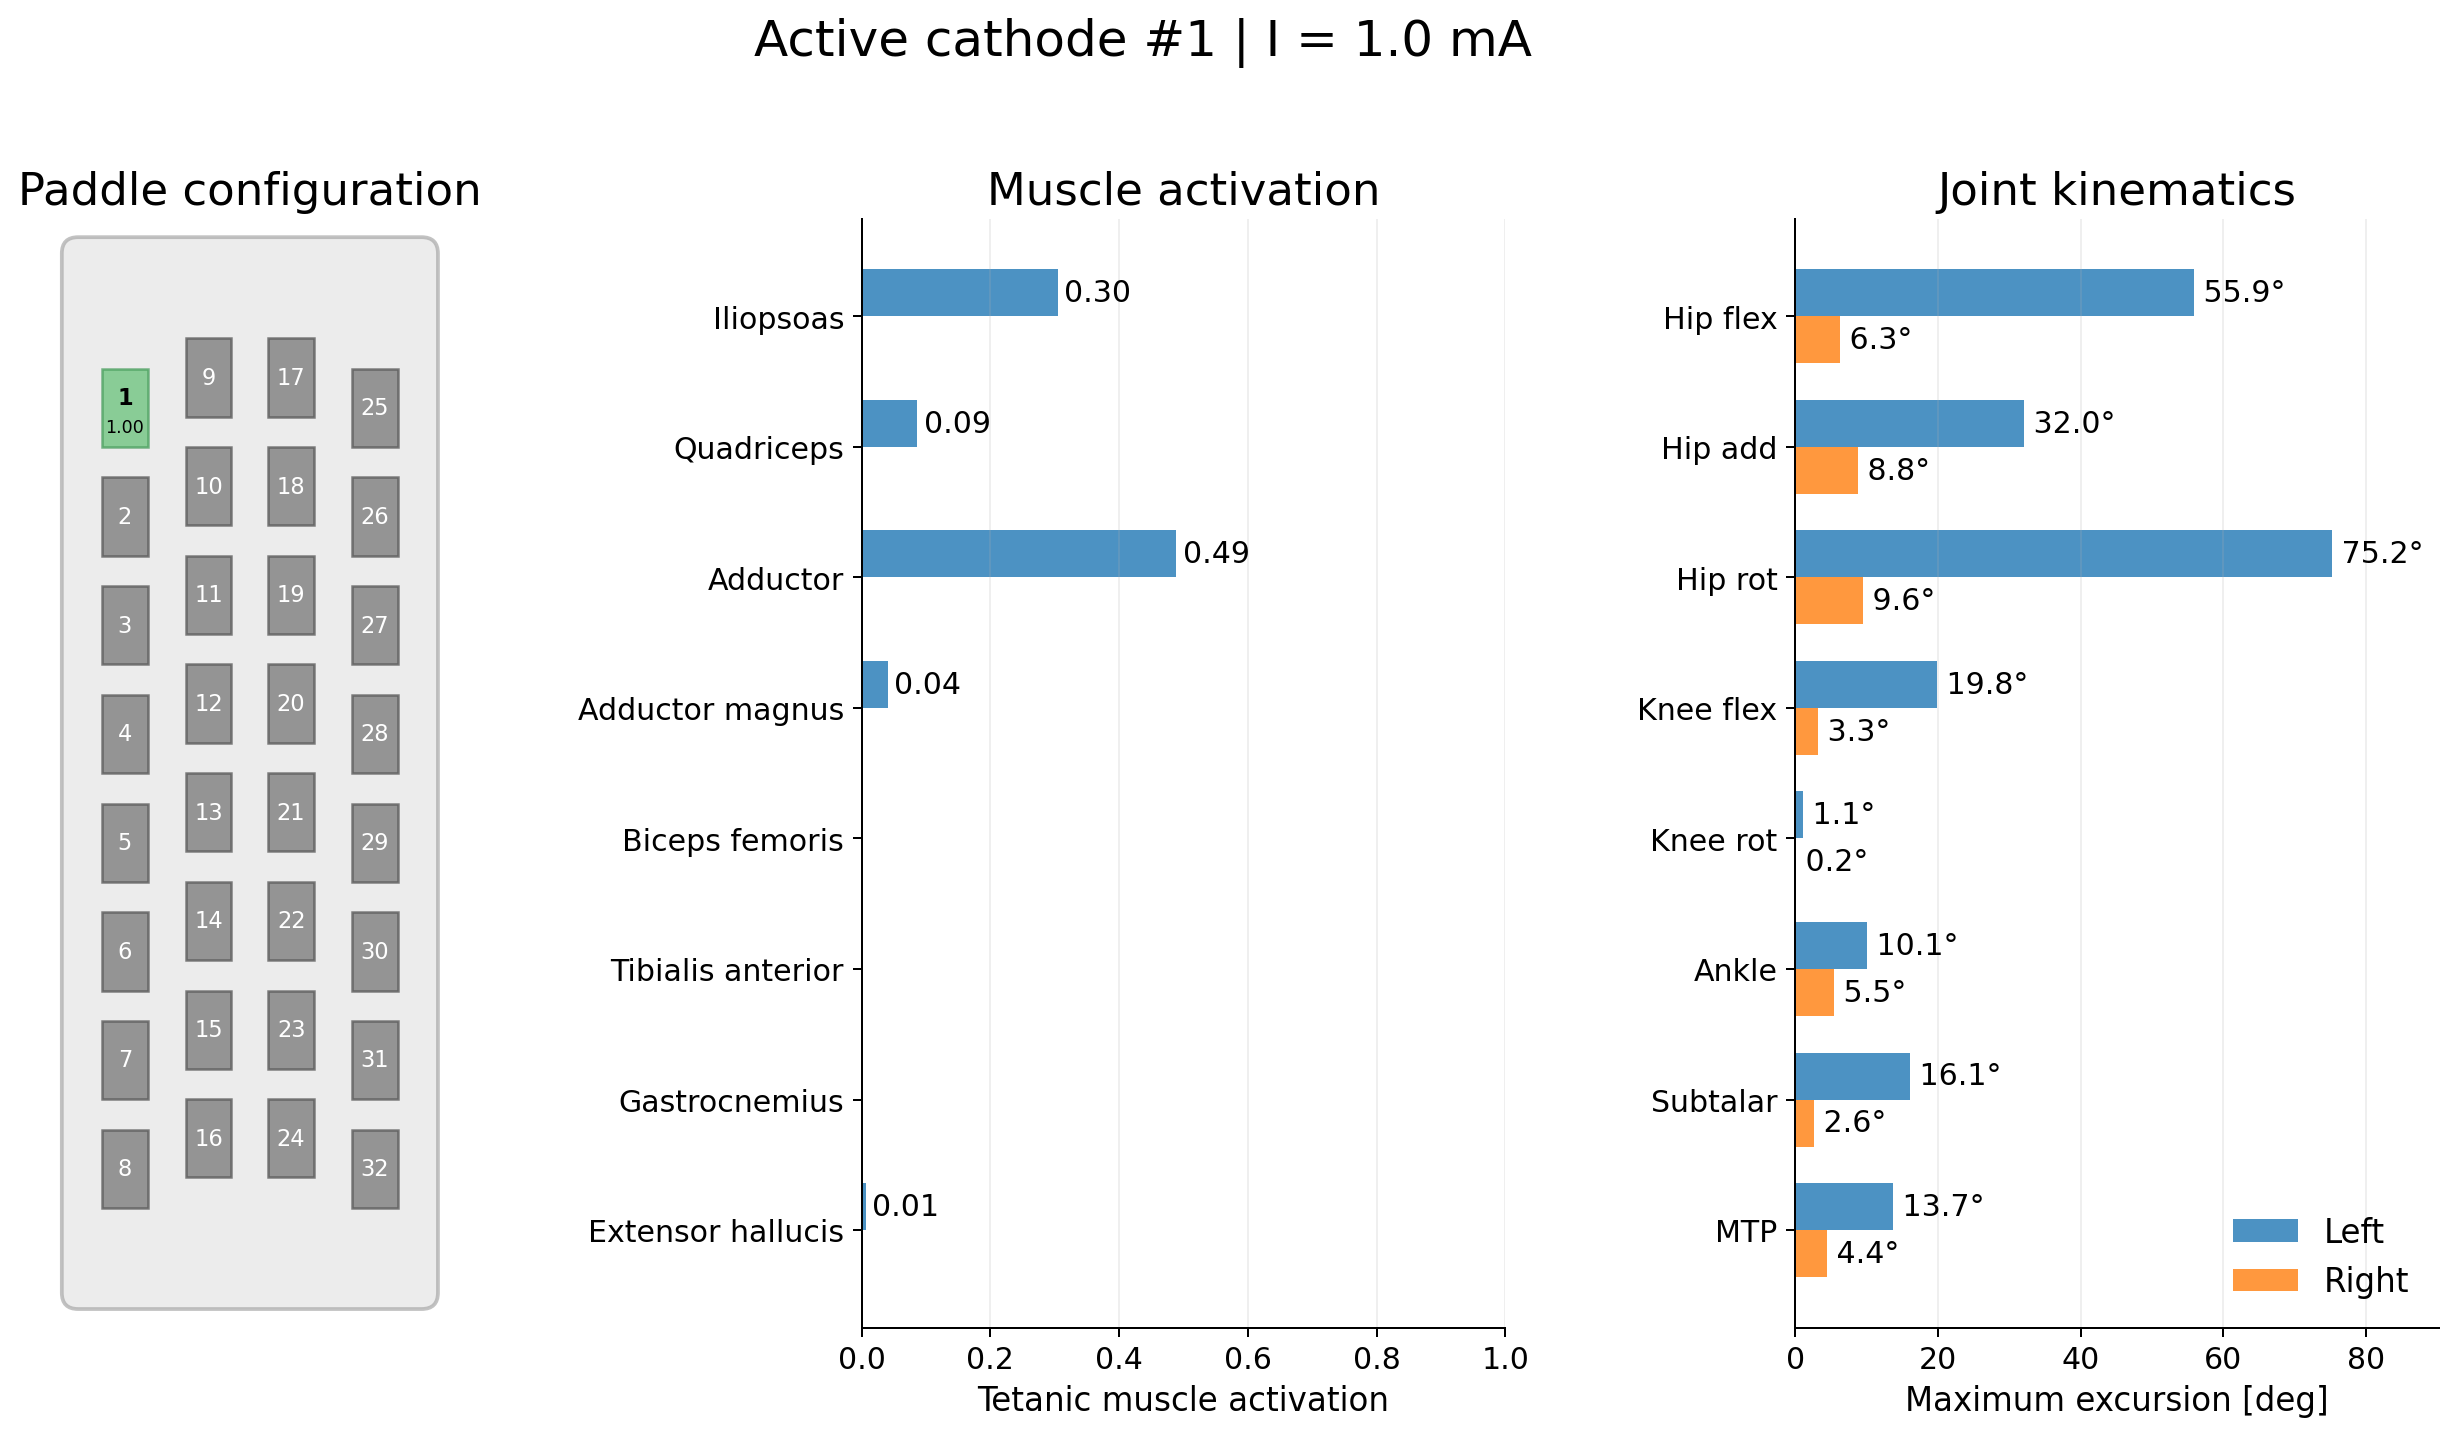

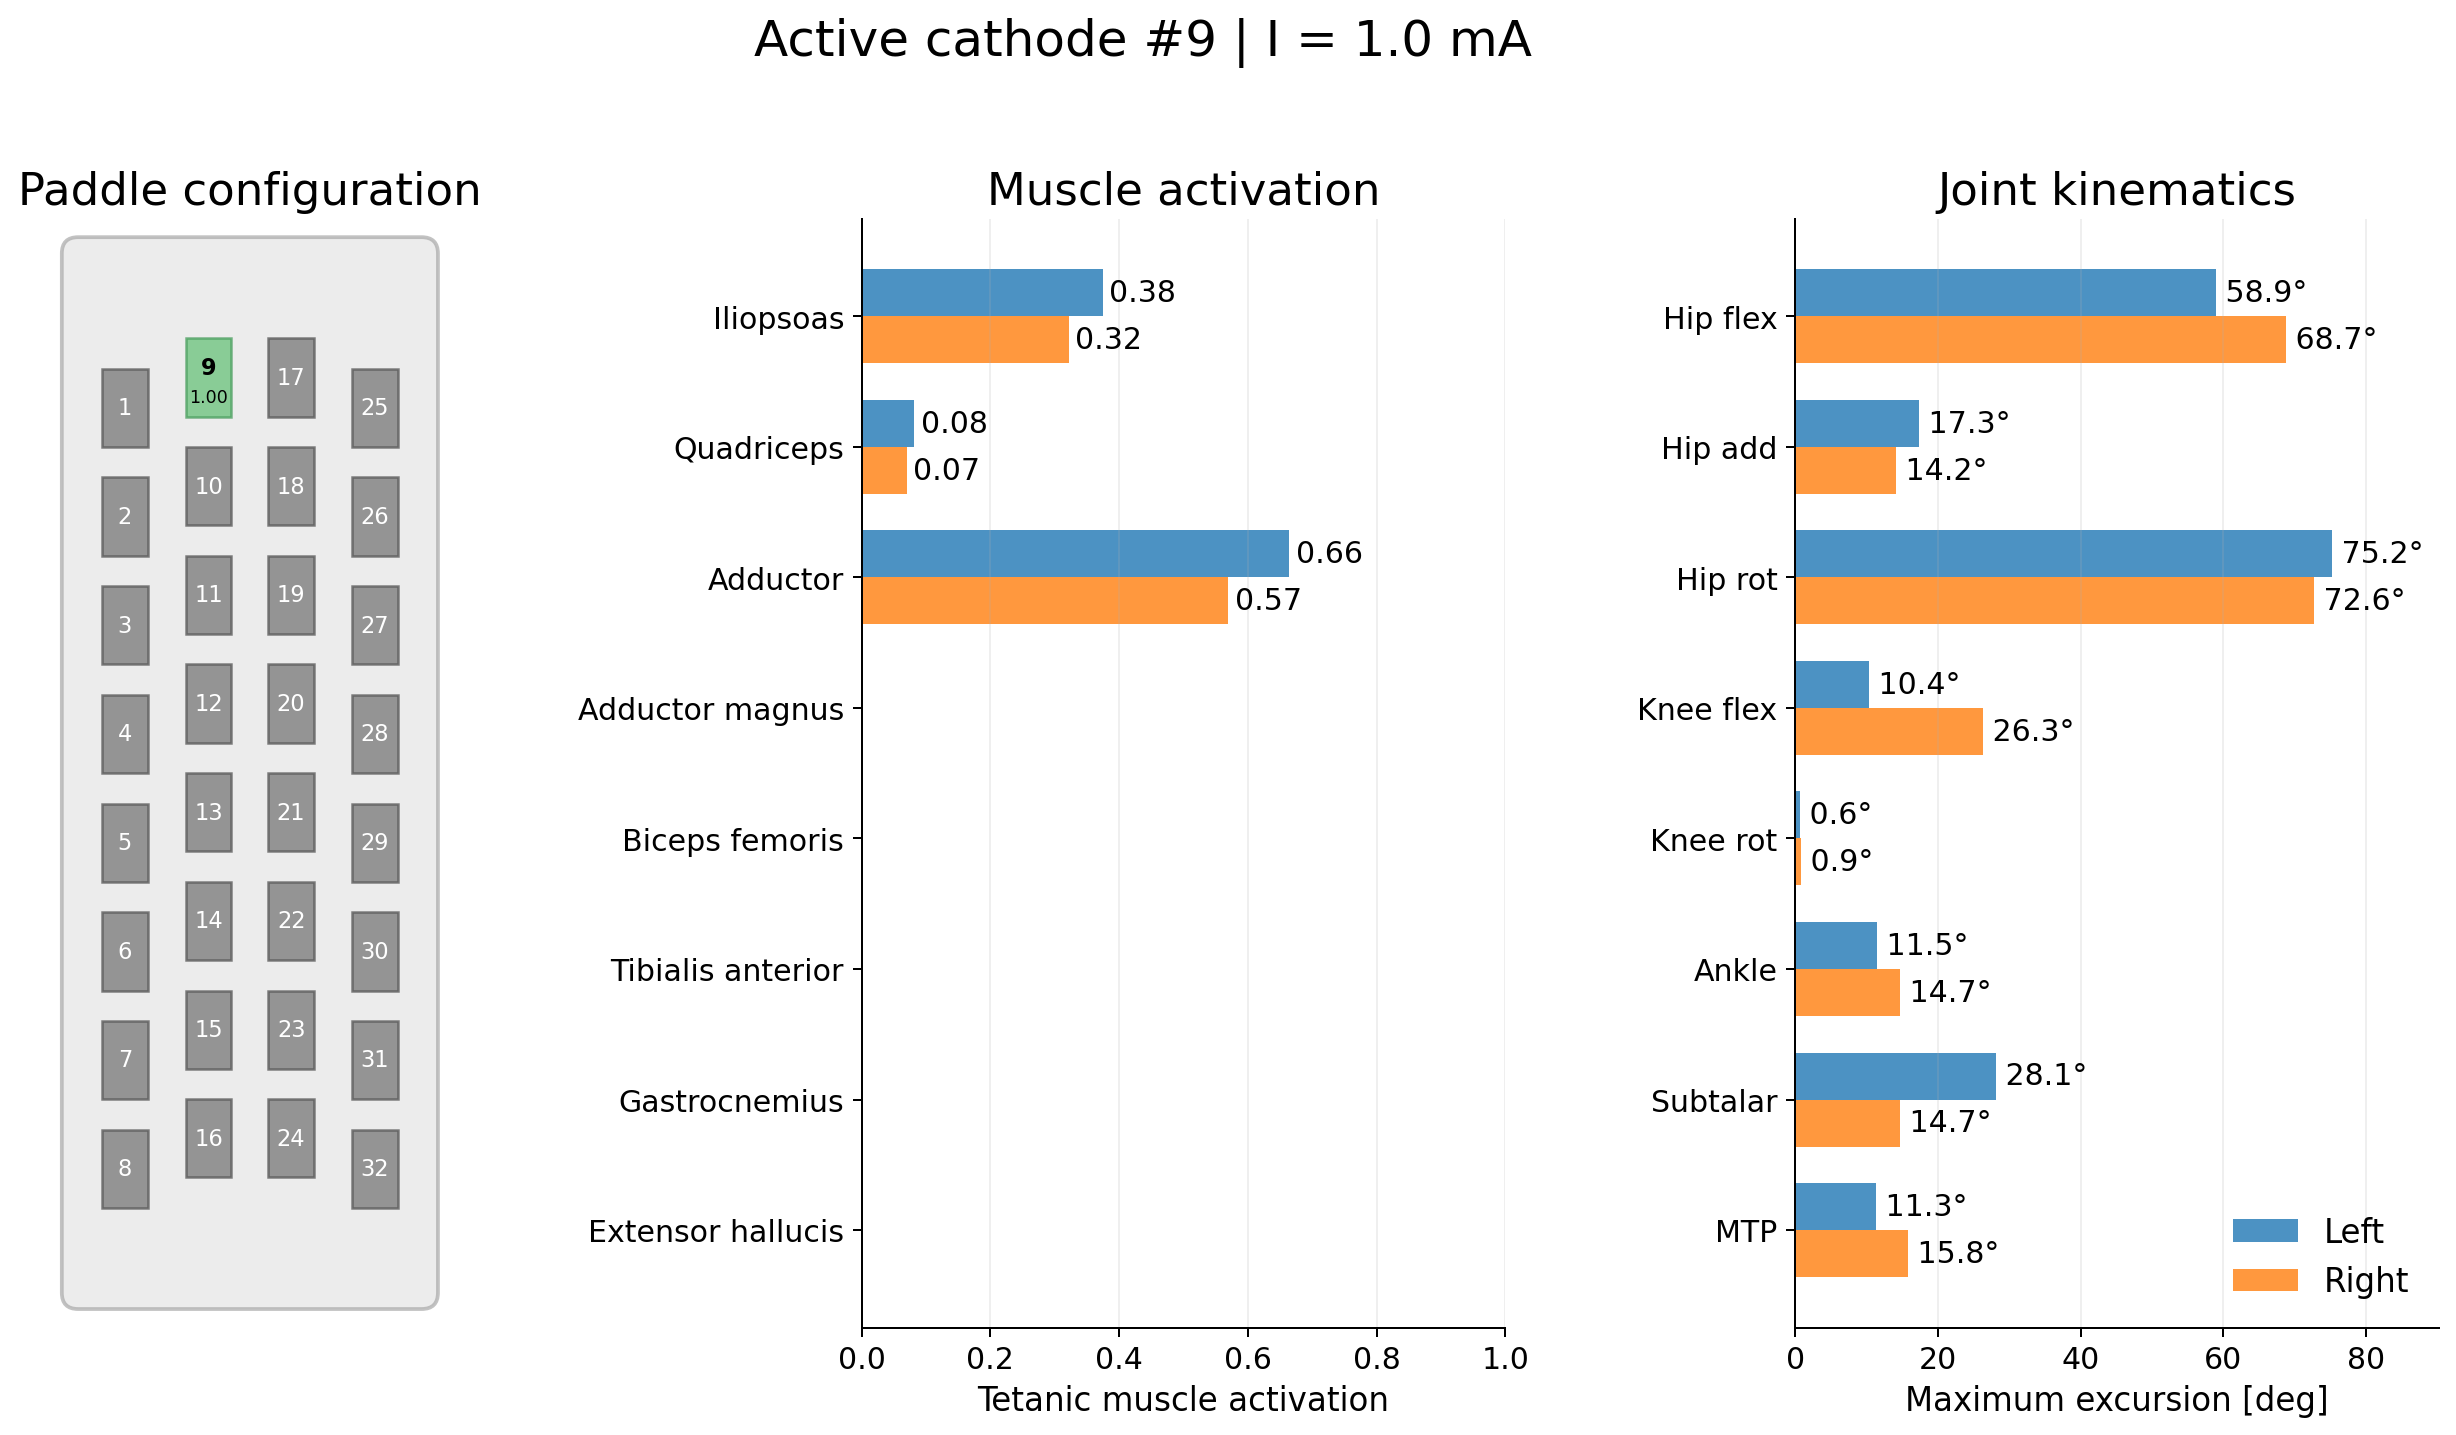

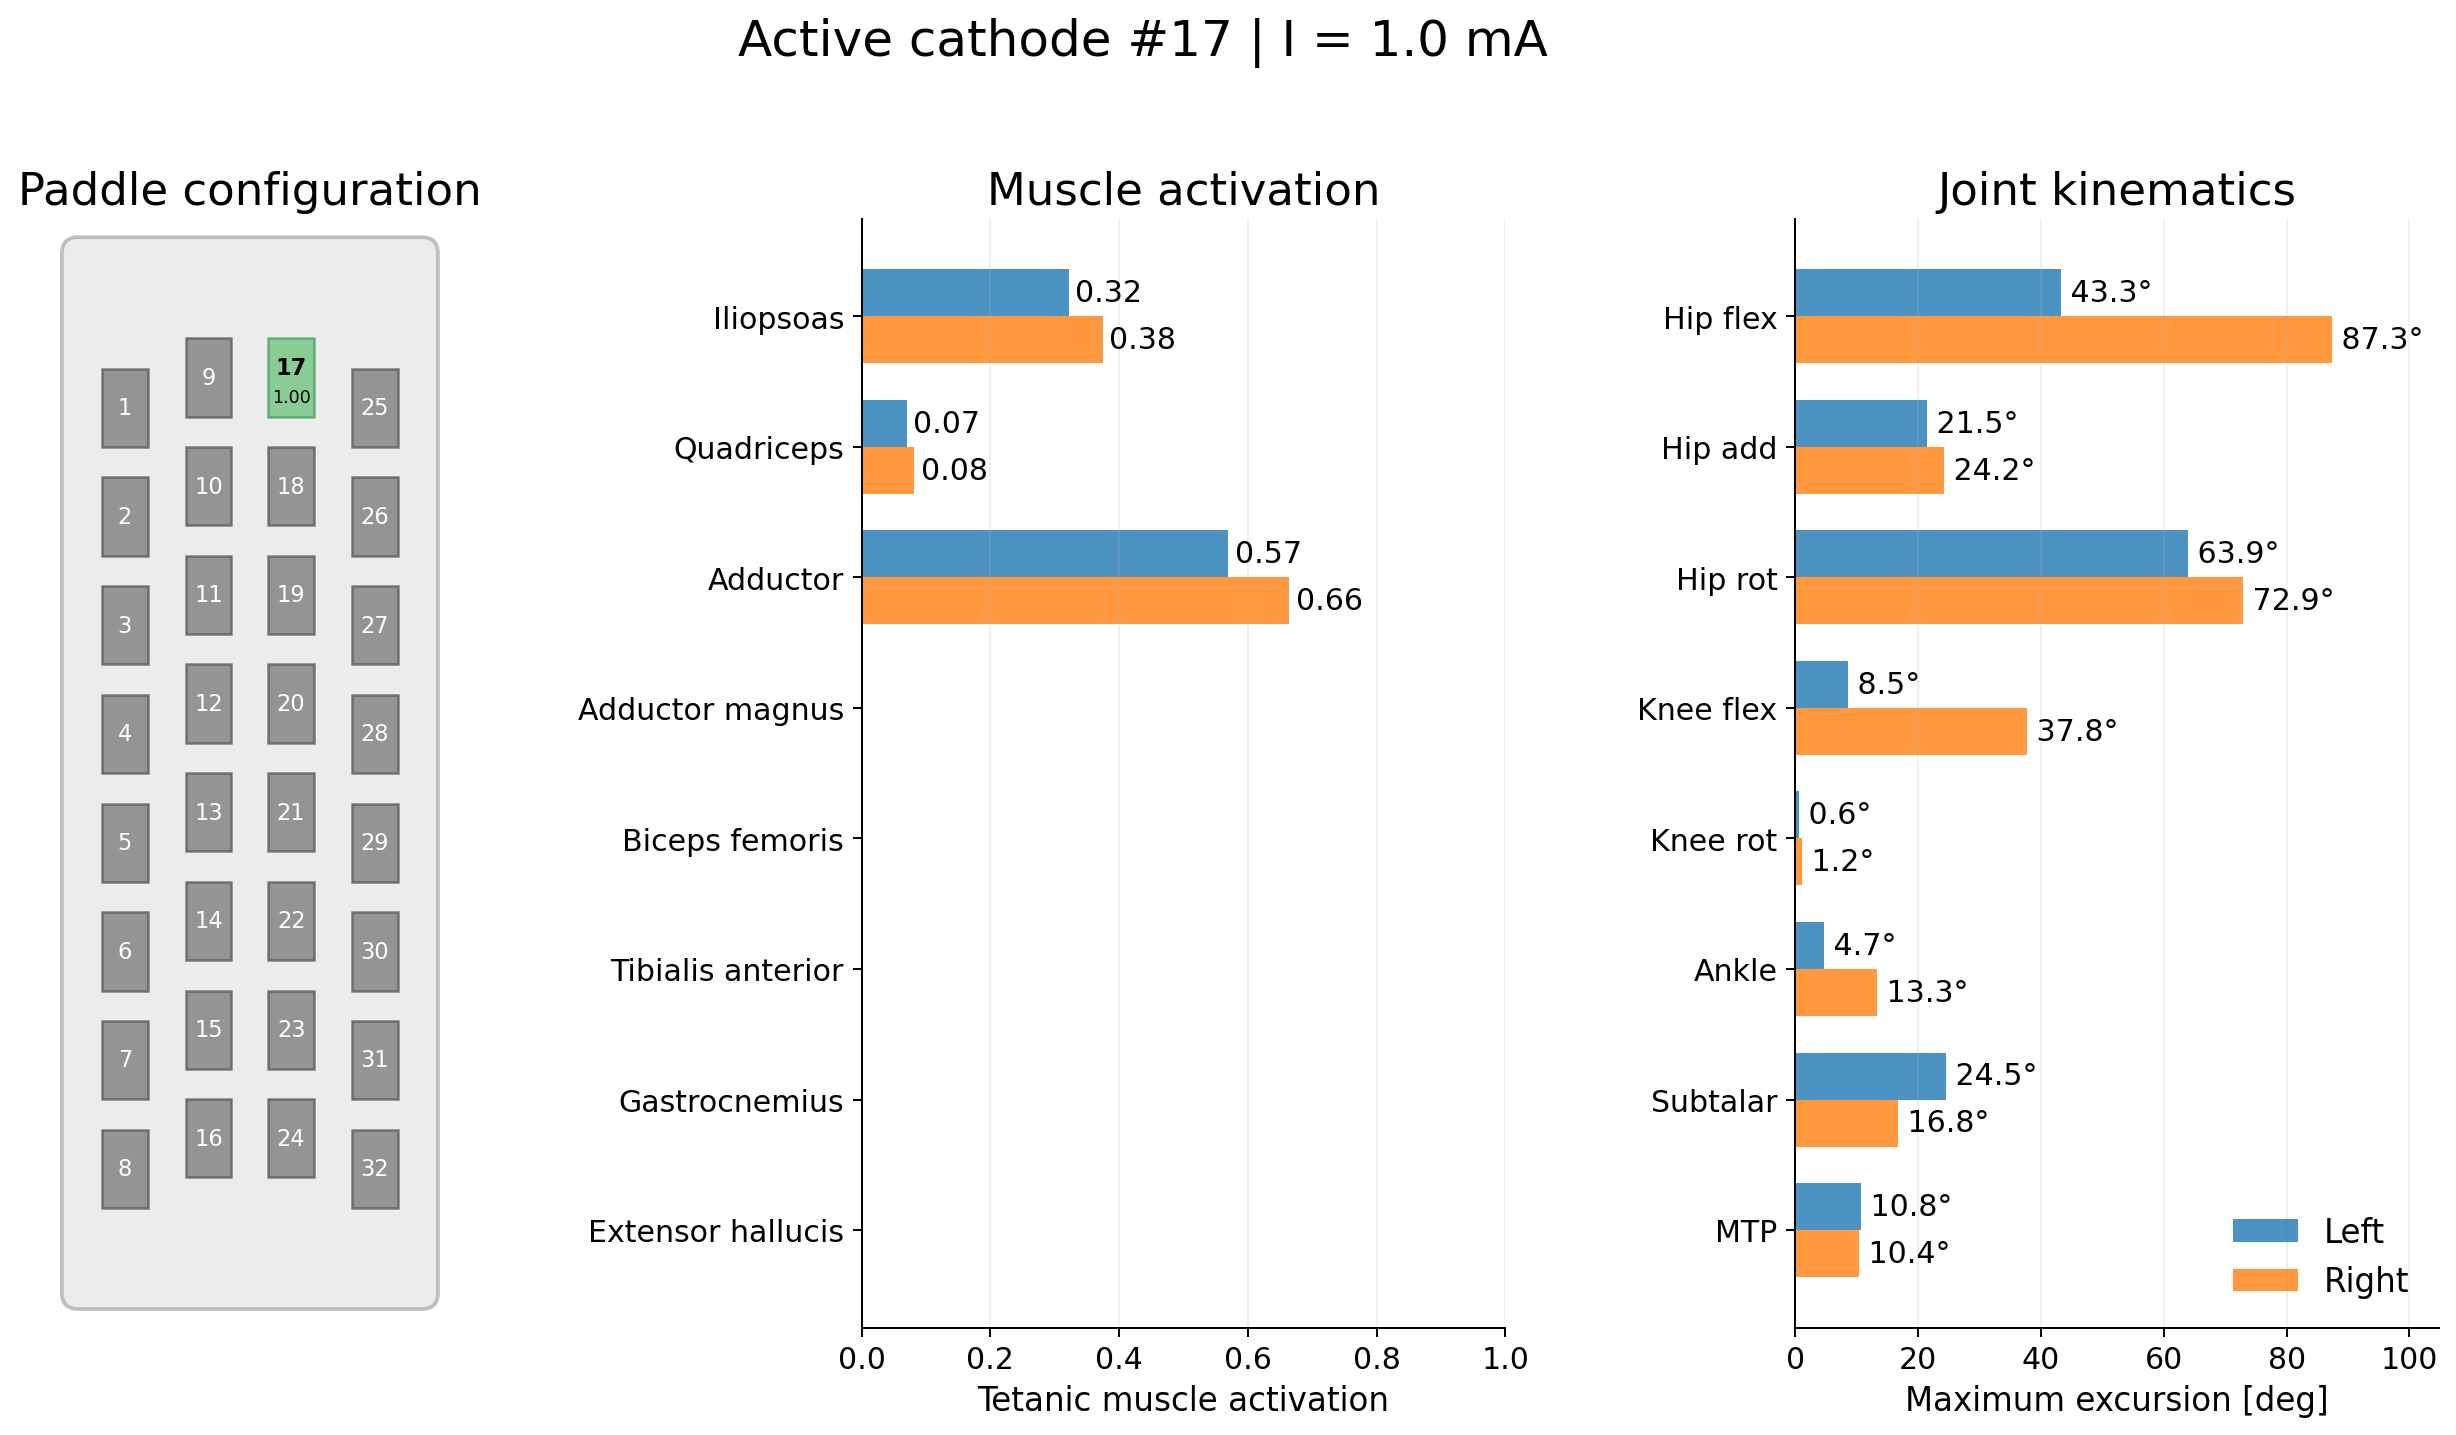

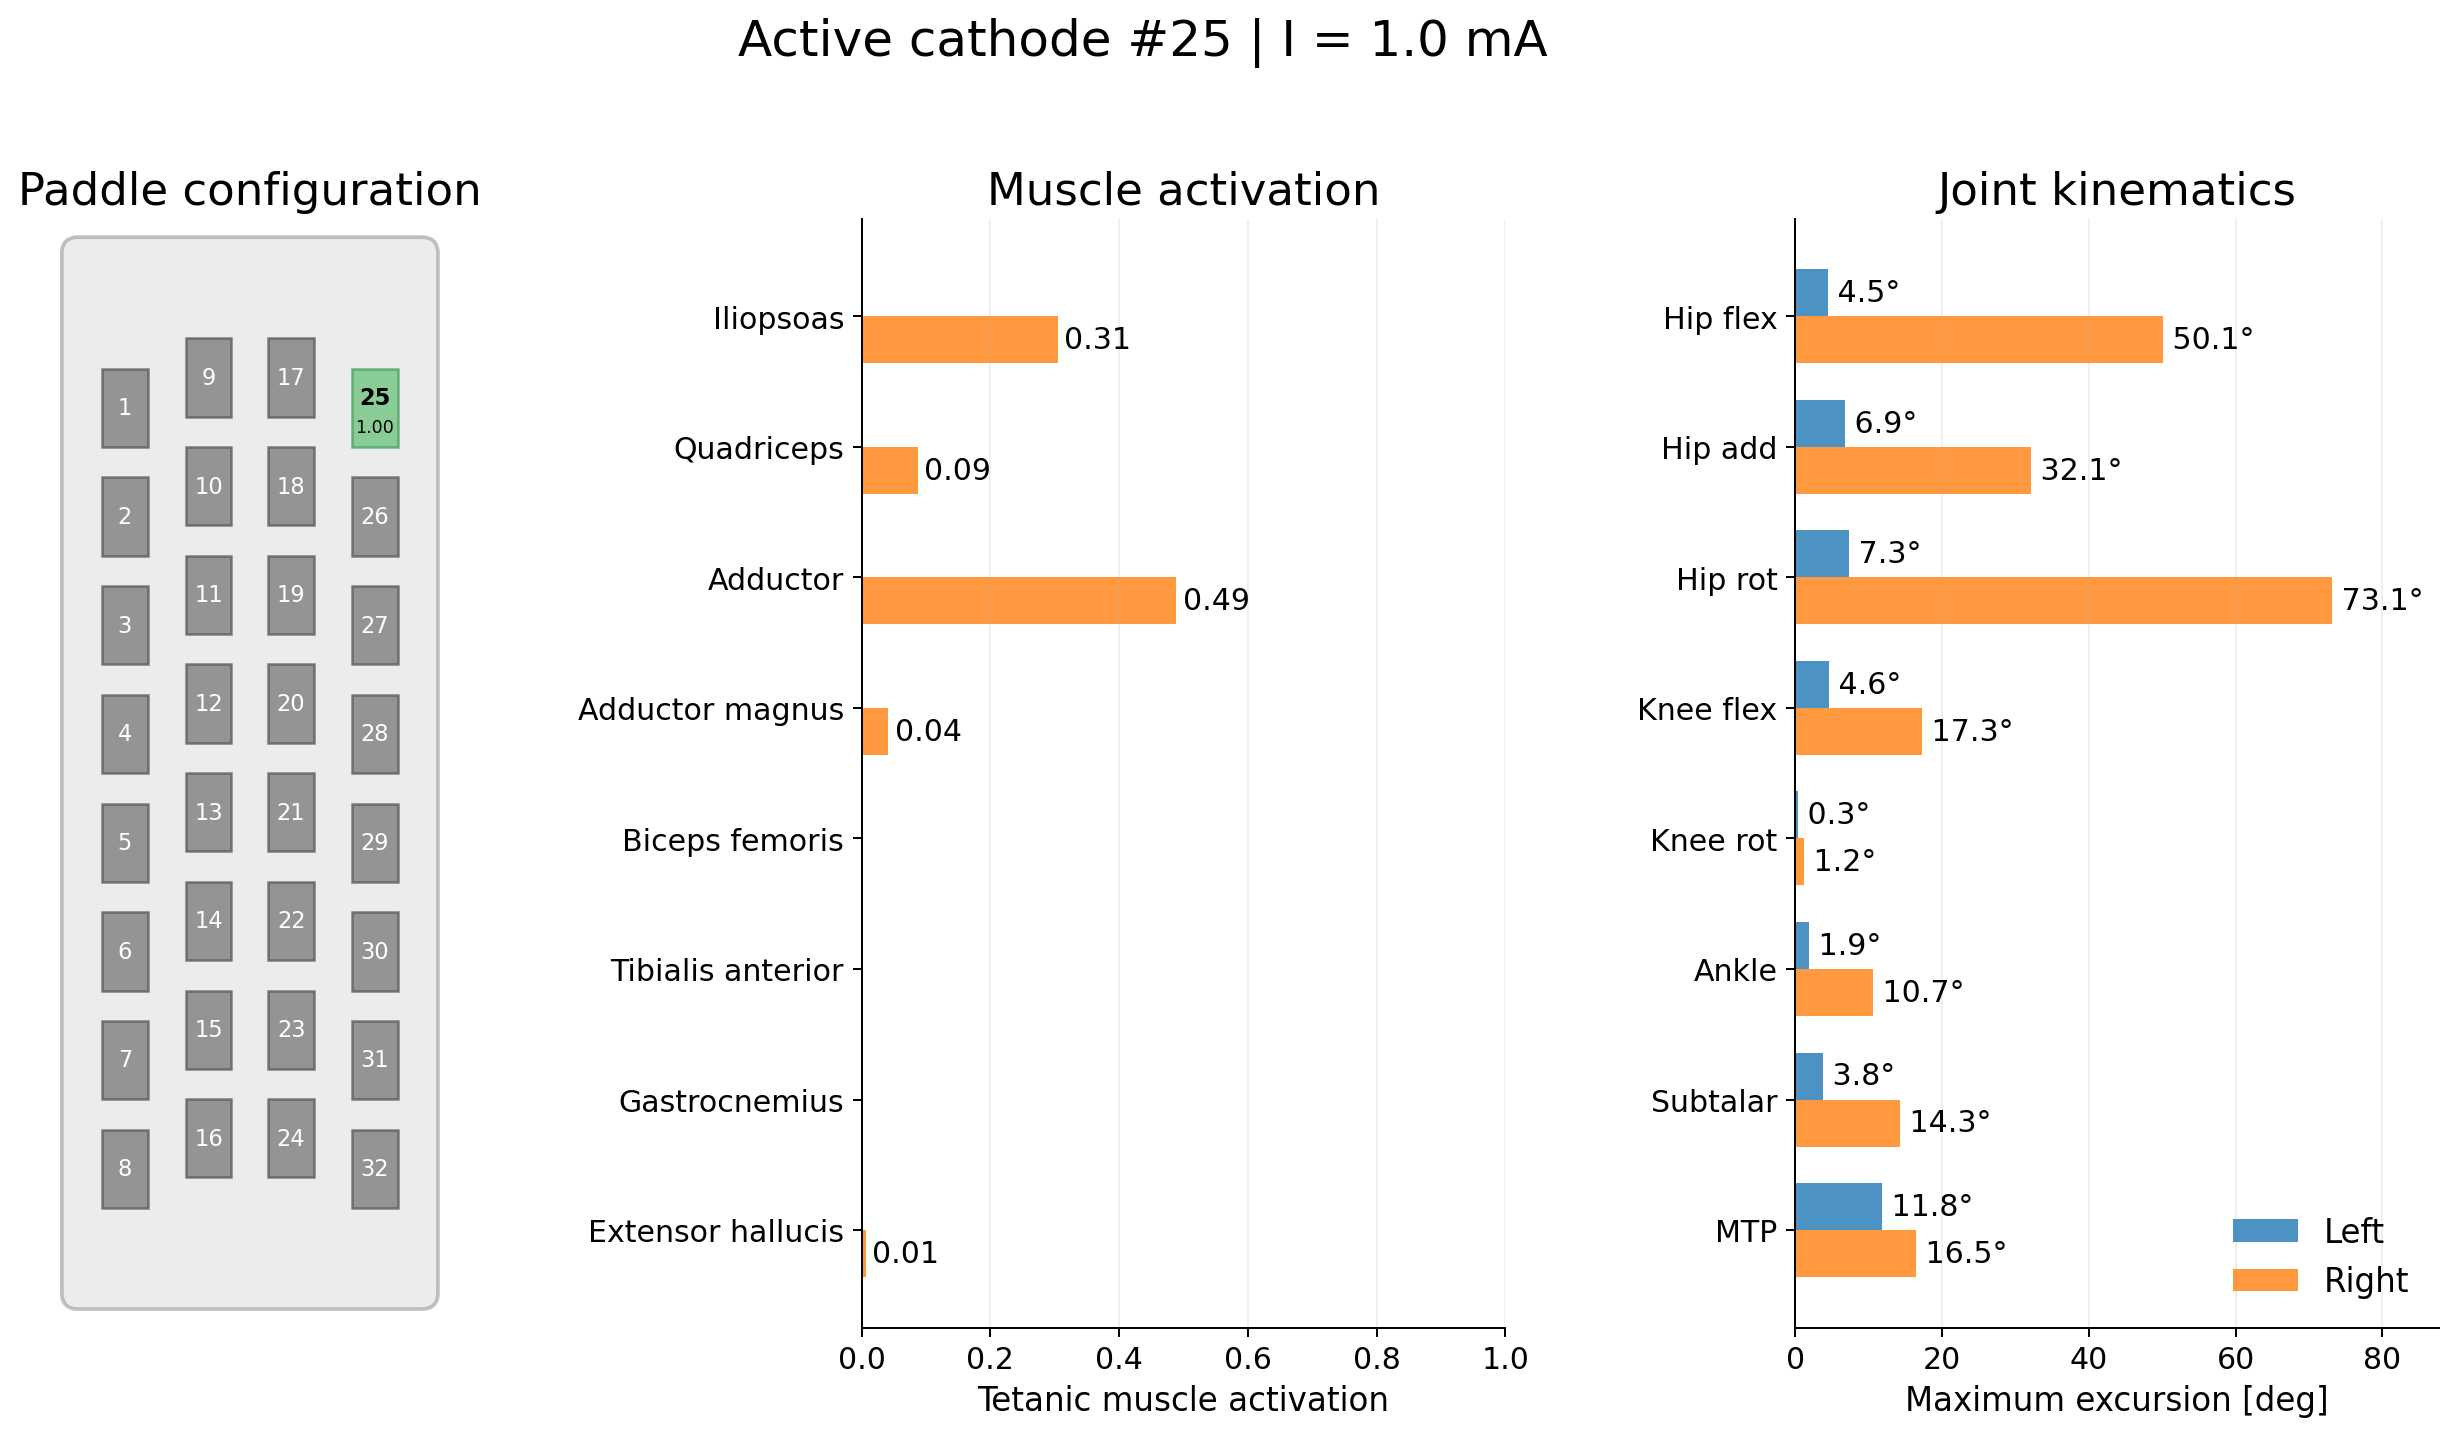

In [24]:
for pattern_name, pattern in STIMULATION_PATTERNS.items():
    plot_pattern_summary(
        pattern_name=pattern_name,
        pattern=pattern,
        result=PATTERN_RESULTS[pattern_name],
    )

## 3.3 Recruitment curves across current amplitude

> **Question:** What changes when we increase stimulation current?

For a fixed electrode, the extracellular potential scales linearly with current. As the amplitude increases, additional representative fibers cross the fixed threshold.

This produces the familiar **recruitment curves**.

We inspect them at three levels:

1. overall Ia recruitment;
2. spinal-segment recruitment;
3. muscle recruitment.

This lets us visualize the dose-response relationship generated by a specific electrode.


Current sweep — electrode 1, threshold = 85.0 mV


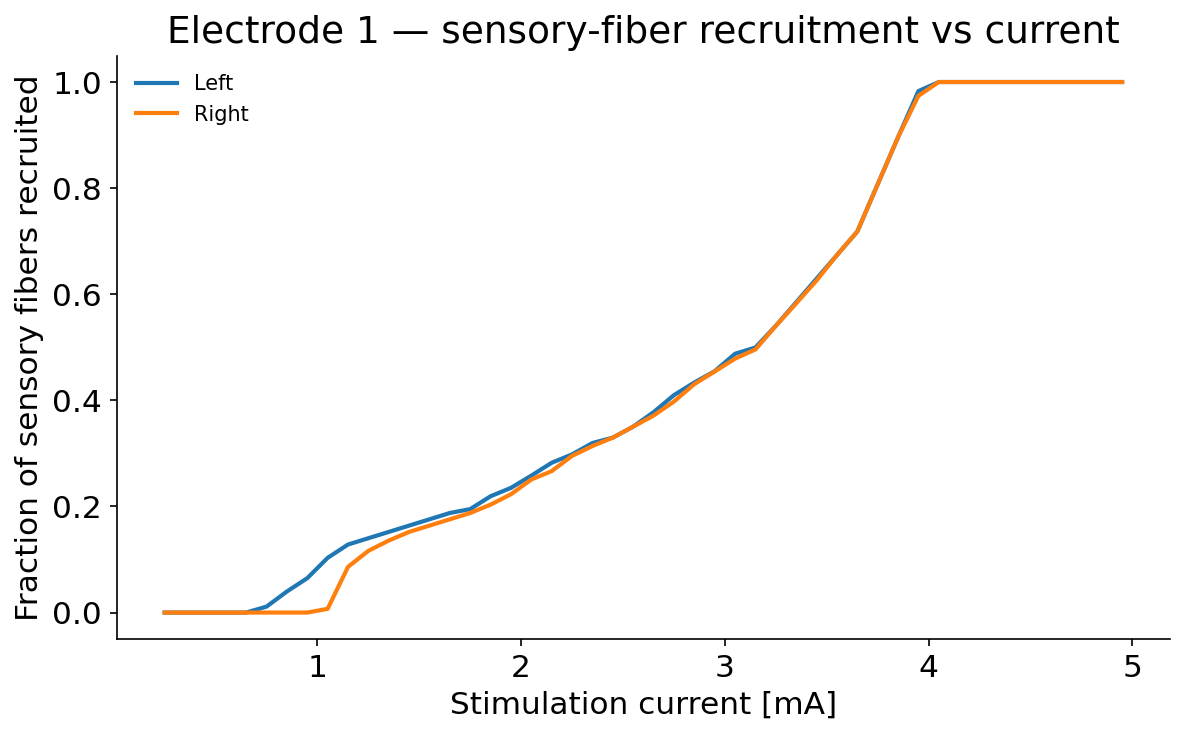

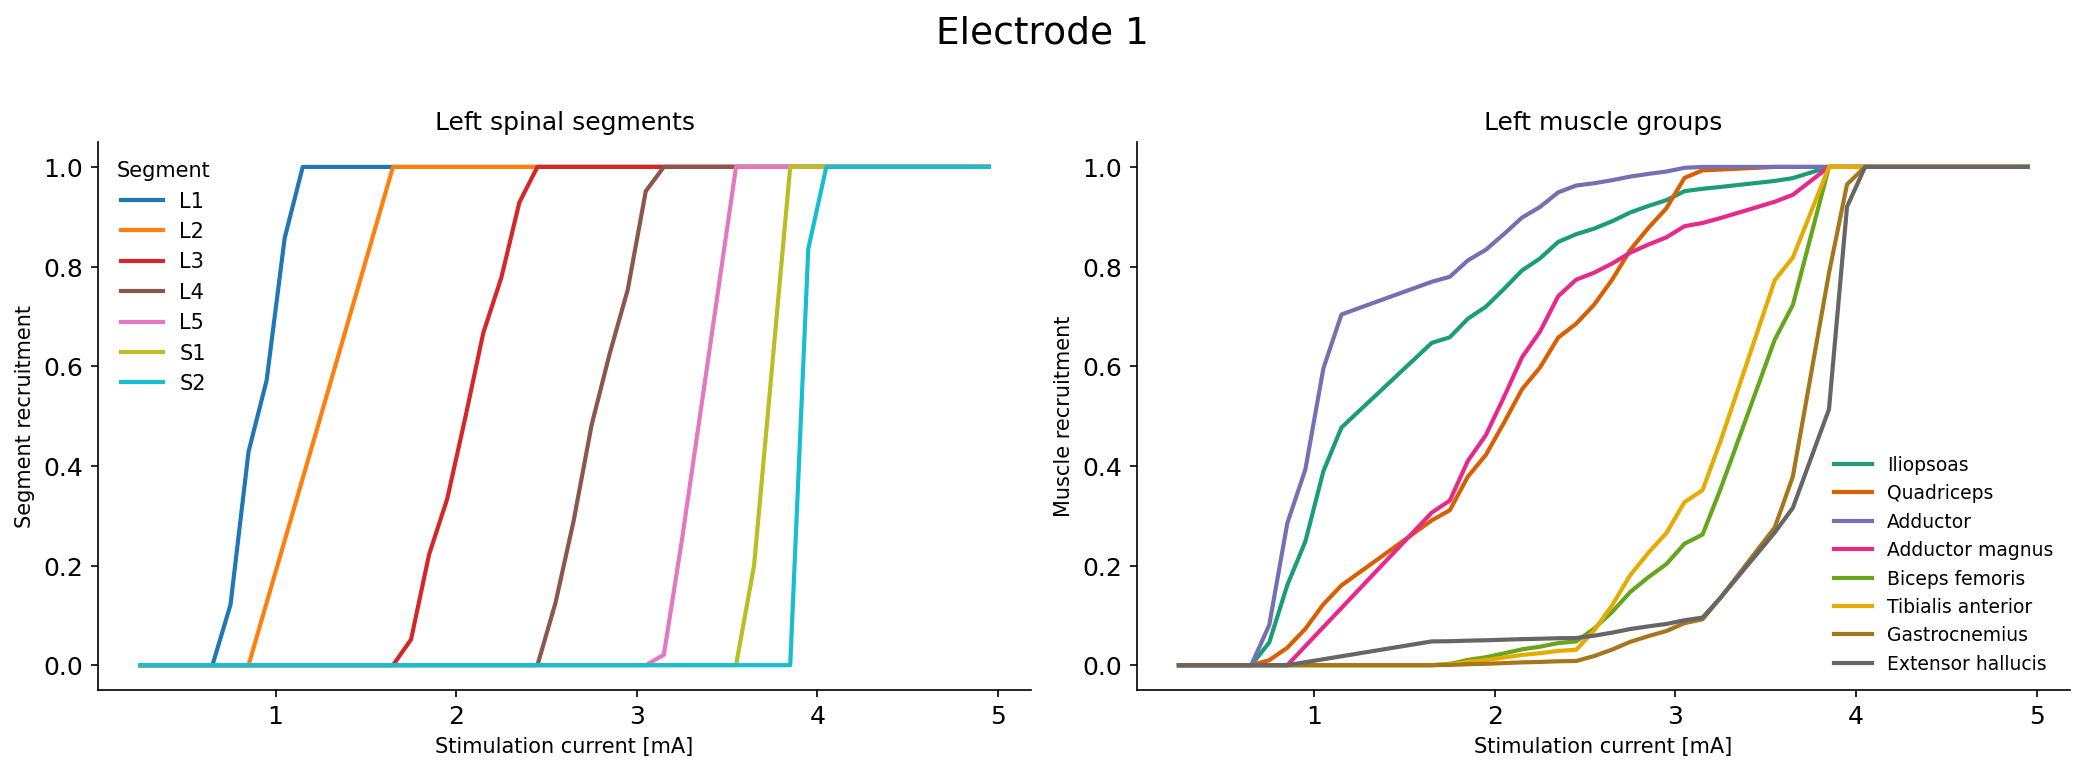

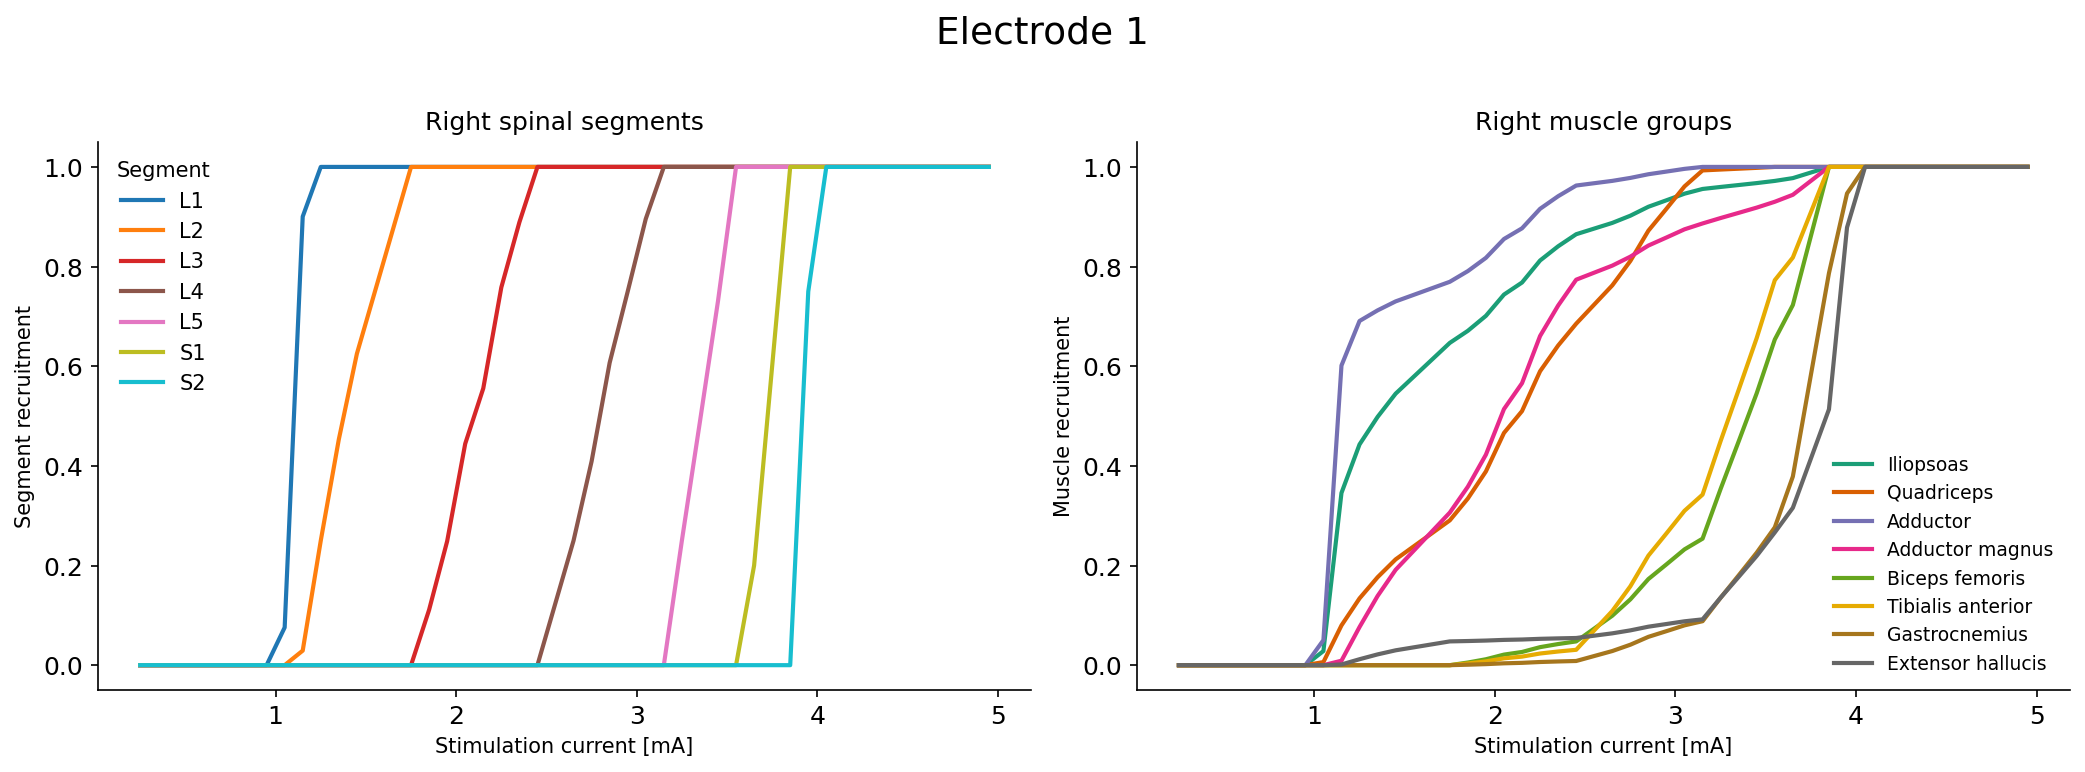

In [25]:
TEST_SITE = 1
CURRENT_VALUES_MA = np.arange(0.25, 5.0, 0.1)

current_rows = []
segment_rows = []
muscle_rows = []

for current_ma in CURRENT_VALUES_MA:

    fiber_result = compute_fiber_activation(
        lfm=lfm,
        site_ids=site_ids,
        stimulation_sites={TEST_SITE: current_ma},
        threshold_mv=FIBER_THRESHOLD_MV,
    )

    fiber_df_i = pd.DataFrame({
        "segment": fiber_segments,
        "rootlet": fiber_rootlets,
        "side": fiber_sides,
        "potential_mv": fiber_result["fiber_potential_mv"],
        "abs_potential_mv": np.abs(fiber_result["fiber_potential_mv"]),
        "active": fiber_result["fiber_activation"].astype(int),
    })

    segment_df_i = compute_segment_recruitment(fiber_df_i)

    muscle_df_i = compute_muscle_recruitment(
        segment_recruitment_df=segment_df_i,
        segments_df=segments_df,
        myotome_df=myotome_df,
    )

    # Overall sensory-fiber recruitment
    for side in ["left", "right"]:

        d = fiber_df_i[fiber_df_i["side"] == side]

        current_rows.append({
            "Current [mA]": current_ma,
            "Side": side,
            "Recruited fibers": int(d["active"].sum()),
            "Total fibers": len(d),
            "Ia recruitment": float(d["active"].mean()),
        })

    # Segment recruitment
    for _, row in segment_df_i.iterrows():
        segment_rows.append({
            "Current [mA]": current_ma,
            "Side": row["side"],
            "Segment": row["segment"],
            "Recruitment": row["recruitment"],
        })

    # Muscle recruitment
    for _, row in muscle_df_i.iterrows():
        muscle_rows.append({
            "Current [mA]": current_ma,
            "Side": row["side"],
            "Muscle": row["muscle"],
            "Recruitment": row["muscle_recruitment"],
        })


CURRENT_TEST_SUMMARY = pd.DataFrame(current_rows)
CURRENT_SEGMENT_SUMMARY = pd.DataFrame(segment_rows)
CURRENT_MUSCLE_SUMMARY = pd.DataFrame(muscle_rows)

print(
    f"Current sweep — electrode {TEST_SITE}, "
    f"threshold = {FIBER_THRESHOLD_MV:.1f} mV"
)

# ------------------------------------------------------------
# Overall sensory-fiber recruitment
# ------------------------------------------------------------

plt.figure(figsize=(8, 5), dpi=150)

for side in ["left", "right"]:

    d = CURRENT_TEST_SUMMARY[
        CURRENT_TEST_SUMMARY["Side"] == side
    ]

    plt.plot(
        d["Current [mA]"],
        d["Ia recruitment"],
        linewidth=2,
        label=side.capitalize(),
    )

plt.xlabel("Stimulation current [mA]", fontsize=15)
plt.ylabel("Fraction of sensory fibers recruited", fontsize=15)
plt.title(
    f"Electrode {TEST_SITE} — sensory-fiber recruitment vs current",
    fontsize=18,
)

plt.ylim(-0.05, 1.05)
plt.tick_params("both", labelsize=15)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Segment and muscle recruitment
# ------------------------------------------------------------

MUSCLE_ORDER = [
    "Iliopsoas",
    "Quadriceps",
    "Adductor",
    "Adductor magnus",
    "Biceps femoris",
    "Tibialis anterior",
    "Gastrocnemius",
    "Extensor hallucis",
]

segment_colors = dict(
    zip(
        SEGMENT_NAMES,
        plt.cm.tab10(np.linspace(0, 1, len(SEGMENT_NAMES))),
    )
)

muscle_colors = dict(
    zip(
        MUSCLE_ORDER,
        plt.cm.Dark2(np.linspace(0, 1, len(MUSCLE_ORDER))),
    )
)

for side in ["left", "right"]:

    fig, ax = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

    # Segment recruitment
    for segment in SEGMENT_NAMES:

        d = CURRENT_SEGMENT_SUMMARY[
            (CURRENT_SEGMENT_SUMMARY["Side"] == side)
            & (CURRENT_SEGMENT_SUMMARY["Segment"] == segment)
        ]

        ax[0].plot(
            d["Current [mA]"],
            d["Recruitment"],
            linewidth=2,
            label=segment,
            color=segment_colors[segment]
        )

    ax[0].set(
        xlabel="Stimulation current [mA]",
        ylabel="Segment recruitment",
        title=f"{side.capitalize()} spinal segments",
    )
    ax[0].set_ylim(-0.05, 1.05)
    ax[0].legend(
        frameon=False,
        title="Segment",
        fontsize=10,
    )

    # Muscle recruitment
    for muscle in MUSCLE_ORDER:

        d = CURRENT_MUSCLE_SUMMARY[
            (CURRENT_MUSCLE_SUMMARY["Side"] == side)
            & (CURRENT_MUSCLE_SUMMARY["Muscle"] == muscle)
        ]

        ax[1].plot(
            d["Current [mA]"],
            d["Recruitment"],
            linewidth=2,
            label=muscle,
            color=muscle_colors[muscle]
        )

    ax[1].set(
        xlabel="Stimulation current [mA]",
        ylabel="Muscle recruitment",
        title=f"{side.capitalize()} muscle groups",
    )
    ax[1].set_ylim(-0.05, 1.05)
    ax[1].legend(
        frameon=False,
        fontsize=9,
    )

    for a in ax:
        a.tick_params(labelsize=12)
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)

    plt.suptitle(
        f"Electrode {TEST_SITE}",
        fontsize=18,
        y=1.02,
    )

    plt.tight_layout()
    plt.show()

### ✅ Take-home message — section 3

The predicted muscle activations drive a neuromusculoskeletal model, allowing stimulation parameters to be translated into simulated joint movement.

## Final take-home message

Throughout this hands-on, we progressively built a computational pipeline that transforms an epidural stimulation protocol into a prediction of lower-limb movement.

Each stage abstracts a different physiological process while preserving the causal relationship between stimulation, neural recruitment, muscle activation, and biomechanics.

<center>

**stimulation protocol**  
↓  
**precomputed FEM solutions**  
↓  
**Lead Field Matrix**  
↓  
**sensory-fiber recruitment**  
↓  
**spinal-segment recruitment**  
↓  
**muscle recruitment**  
↓  
**muscle activation dynamics**  
↓  
**MuJoCo forward dynamics**  
↓  
**joint kinematics**

</center>

Although several simplifying assumptions were introduced, this framework illustrates the fundamental concepts behind computational neuromusculoskeletal modeling for epidural spinal cord stimulation and provides a foundation for exploring more physiologically detailed models.

# References

1. **Capogrosso M, et al.** *A computational model for epidural electrical stimulation of spinal sensorimotor circuits.* Journal of Neuroscience, 2013.

2. **Schirmer CM, et al.** *Heuristic map of myotomal innervation in humans using direct intraoperative nerve root stimulation.* Journal of Neurosurgery: Spine, 2011.

3. **Romeni S, et al.** *Tutorial: a computational framework for the design and optimization of peripheral neural interfaces.* Nature Protocols, 2020.

4. **Thelen DG.** *Adjustment of muscle mechanics model parameters to simulate dynamic contractions in older adults.* Journal of Biomechanical Engineering, 2003.

5. **Winters JM.** *An improved muscle-reflex actuator for use in large-scale neuromusculoskeletal models.* Annals of Biomedical Engineering, 1995.

6. **Zajac FE.** *Muscle and tendon: properties, models, scaling, and application to biomechanics and motor control.* Critical Reviews in Biomedical Engineering, 1989.

### Further reading

- **OpenSim documentation (activation dynamics):** https://opensimconfluence.atlassian.net/wiki/
- **NEURON documentation:** https://nrn.readthedocs.io/en/latest/